# Objectif du fichier

Analyse descriptive des résultats du clusturing selon les années.
Pour cela plusieurs étapes:
- on récupères les données clusterisées.
- on calcule les différentes métriques pour chaque années.
- on passe à l'année suivante.

Les métriques d'intérêt pour les statistiques descriptives sont : évolution de la surface industrialisée, évolution du nombre de clusters, proportion des bâtiments isolés, nombre de meta clusters, taux de conversion d'une année sur l'autre des points isolés en cluster.


## DEPUIS MI-NOV

Le fichier sert à explorer les données : BDTOPO et Sitadel, dans le but de comprendre ce qui est exploitable

In [1]:
!pip install geopandas pandas numpy shapely matplotlib requests beautifulsoup4 boto3 py7zr

In [2]:
### TELECHARGEMENT PACKAGES
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import re
import os
import subprocess
import boto3
import tempfile
import py7zr 
import glob
from credentials import s3
from fonctions import load_gpkg, gdf_DBSCAN, plot_DB_epsilon#, courbe_DB_epsilon
from fonctions import download_to_SSPCloud
from fonctions import upload_to_onyxia

In [8]:
gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_all_1000m3.gpkg")
sauv=gdf.copy()

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_all_1000m3.gpkg ...
Chargement réussi (4120762 lignes)


In [9]:
gdf['Dep'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,
       53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69,
       70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86,
       87, 88, 89, 90, 91, 92, 93, 94, 95])

In [118]:
gdf=sauv.copy()

In [10]:
gdf=gdf[gdf['Dep'].isin([59,2,80,62])]

In [11]:
gdf= gdf[gdf.geometry.area > 1000] 

## Etude du panel

Plot nb ID d'un département vs (nb ID dep - nb ID aussi dans un autre dep) => regarder 2019 ou 2020

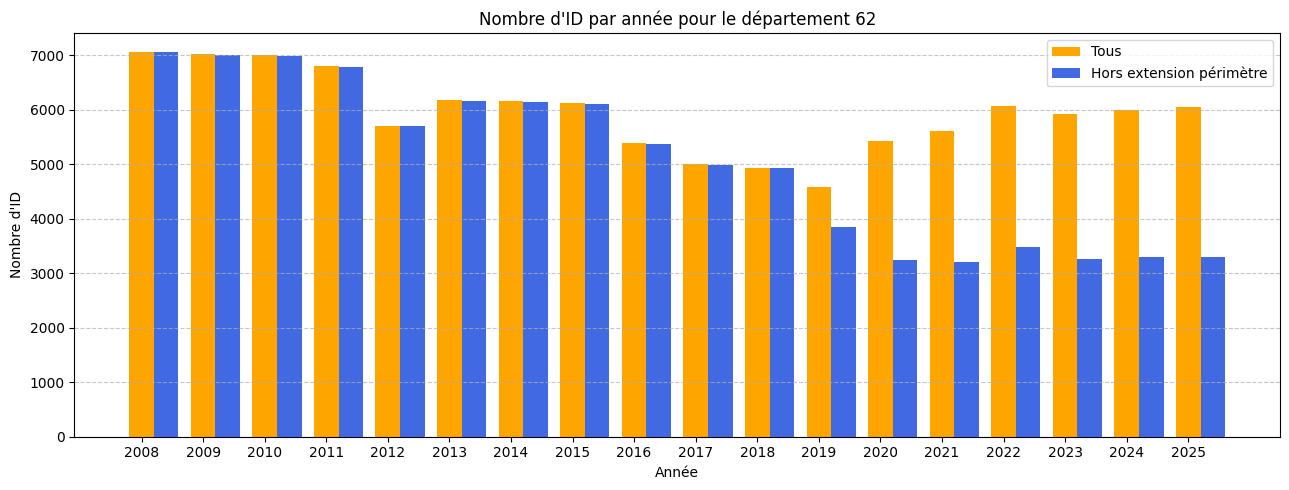

In [13]:
import numpy as np
import matplotlib.pyplot as plt

dep_target = 62
counts = gdf[gdf['Dep'] == dep_target].groupby('Annee')['ID'].count()
counts_new = []
gdf_other = gdf[gdf['Dep'] != dep_target]
annees = sorted(counts.index)

for annee_t in annees:
    ids_t = set(gdf[(gdf['Dep']==dep_target) & (gdf['Annee']==annee_t)]['ID'])
    ids_prev_other = set(gdf_other[gdf_other['Annee'] < annee_t]['ID'])
    ids_new = ids_t - ids_prev_other
    counts_new.append(len(ids_new))

# Graphique
x = np.array(annees)
offset = 0.4
plt.figure(figsize=(13,5))
plt.bar(x, counts.values, width=0.4, label='Tous', color='orange')
plt.bar(x + offset, counts_new, width=0.4, label='Hors extension périmètre', color='royalblue')
plt.title(f"Nombre d'ID par année pour le département {dep_target}")
plt.xlabel("Année")
plt.ylabel("Nombre d'ID")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(annees)
plt.legend()
plt.tight_layout()
plt.show()


Plot nb ID vs nb localisations uniques 

Traitement année 2008
Traitement année 2009
Traitement année 2010
Traitement année 2011
Traitement année 2012
Traitement année 2013
Traitement année 2014
Traitement année 2015
Traitement année 2016
Traitement année 2017
Traitement année 2018
Traitement année 2019
Traitement année 2020
Traitement année 2021
Traitement année 2022
Traitement année 2023
Traitement année 2024
Traitement année 2025


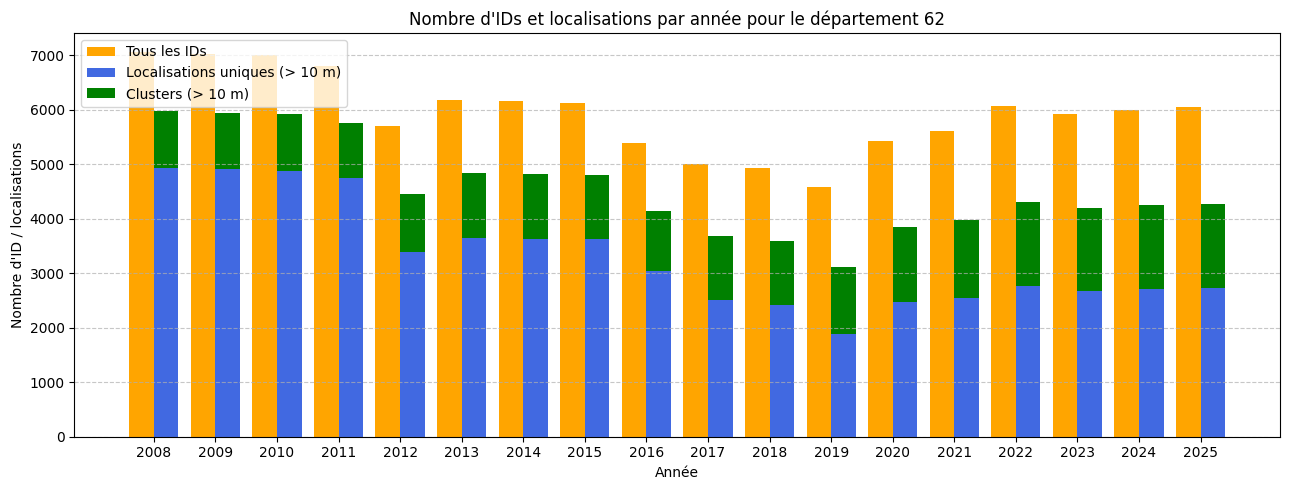

In [149]:
dep_target = 62
rayon = 10  # tolérance en mètres
annees = sorted(gdf['Annee'].unique())

# IDs totaux par année
counts_total = gdf[gdf['Dep'] == dep_target].groupby('Annee')['ID'].count()

# Comptage des localisations uniques et clusters
counts_unique = []
counts_clusters = []

for annee_t in annees:
    print(f"Traitement année {annee_t}")
    gdf_t = gdf[(gdf['Dep'] == dep_target) & (gdf['Annee'] == annee_t)].copy()
    sindex_t = gdf_t.sindex
    
    count_unique = 0
    count_cluster = 0
    used = set()
    
    for idx, geom in gdf_t.geometry.items():
        if idx in used:
            continue
        
        # Tous les points dans le rayon
        candidates = list(sindex_t.intersection(geom.buffer(rayon).bounds))
        possible = gdf_t.iloc[candidates]
        indices = possible.index.tolist()
        
        used.update(indices)  # marquer tous les points comme utilisés
        
        if len(indices) == 1:
            count_unique += 1
        else:
            count_cluster += 1
    
    counts_unique.append(count_unique)
    counts_clusters.append(count_cluster)

#plot
x = np.array(annees)
width = 0.4
plt.figure(figsize=(13,5))

# Barre totale (IDs)
plt.bar(x - width/2, counts_total.values, width=width, label='Tous les IDs', color='orange')

# Barres empilées : unique + clusters
plt.bar(x + width/2, counts_unique, width=width, label=f'Localisations uniques (> {rayon} m)', color='royalblue')
plt.bar(x + width/2, counts_clusters, width=width, bottom=counts_unique, label=f'Clusters (> {rayon} m)', color='green')

plt.title(f"Nombre d'IDs et localisations par année pour le département {dep_target}")
plt.xlabel("Année")
plt.ylabel("Nombre d'ID / localisations")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(annees)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

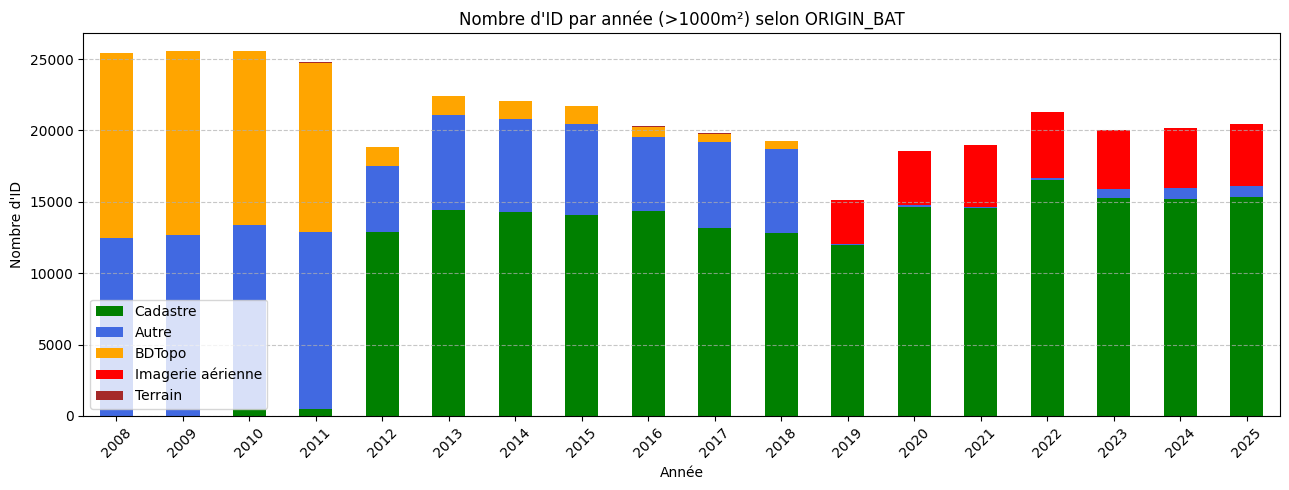

In [14]:
counts = gdf.groupby(['Annee', 'ORIGIN_BAT'])['ID'].count().unstack(fill_value=0)

color_map = {
    "Cadastre": "green",
    "Autre": "royalblue",
    "BDTopo": "orange",
    "Imagerie aérienne": "red",
    "NR": "purple",
    "Terrain": "brown"
}

ordered_origins = ["Cadastre", "Autre", "BDTopo", "Imagerie aérienne", "Terrain"]
counts_ordered = counts[ordered_origins]  # réordonner

# Plot stacked bar avec vecteur couleur fixe
counts_ordered.plot(kind='bar', stacked=True, figsize=(13,5),
                    color=[color_map[origin] for origin in ordered_origins])

plt.title("Nombre d'ID par année (>1000m²) selon ORIGIN_BAT")
plt.xlabel("Année")
plt.ylabel("Nombre d'ID")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

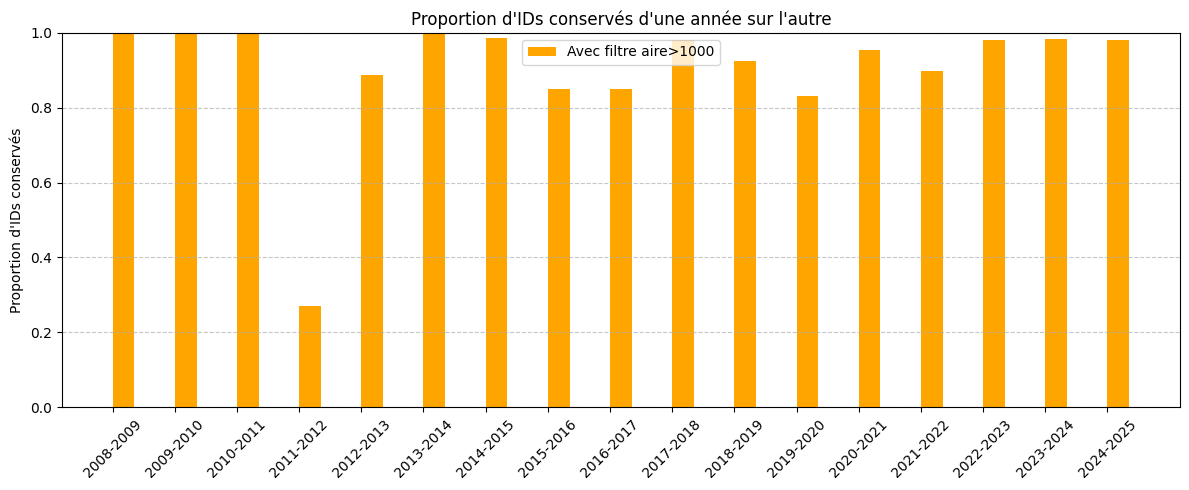

In [15]:
def calcul_retention(df):
    annees = sorted(df['Annee'].unique())
    retention = {}

    for i in range(len(annees) - 1):
        annee_prev = annees[i]
        annee_t = annees[i + 1]

        ids_prev = set(df.loc[df['Annee'] == annee_prev, 'ID'])
        ids_t = set(df.loc[(df['Dep'] == dep_target) & (df['Annee'] == annee_t), 'ID'])#ids_t = set(df.loc[df['Annee'] == annee_t, 'ID'])

        # proportion des IDs en t déjà présentes en t-1
        proportion = len(ids_t & ids_prev) / len(ids_t) if len(ids_t) > 0 else None

        retention[f"{annees[i]}-{annees[i+1]}"] = proportion

    return retention


retention_full = calcul_retention(gdf)

df_retention = pd.DataFrame({
    "Transition": list(retention_full.keys()),
    "Avec_filtre": list(retention_full.values())
})

#plot
x = range(len(df_retention))
width = 0.35
plt.figure(figsize=(12,5))
plt.bar([i + width/2 for i in x], df_retention["Avec_filtre"], width=width, label='Avec filtre aire>1000',  color='orange')
plt.xticks(x, df_retention["Transition"], rotation=45)
plt.ylabel("Proportion d'IDs conservés")
plt.title("Proportion d'IDs conservés d'une année sur l'autre")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_76302/1779100407.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_plot = pd.DataFrame(index=transitions, columns=origins_order).fillna(0)
/tmp/ipykernel_76302/1779100407.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.47602256699576867' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_plot.at[transitions[i], origin] = count_origin / len(ids_t)  # proportion sur t
/tmp/ipykernel_76302/1779100407.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5036828083372512' has dtype incompatible with int64, please explicitly cast to a compatibl

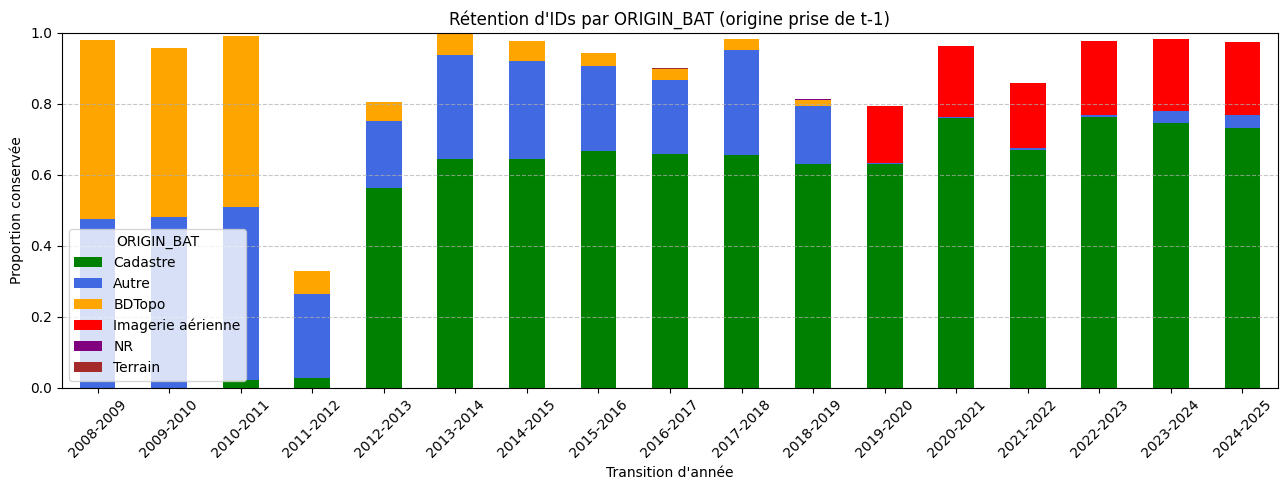

In [16]:
# Liste des ORIGIN_BAT dans l'ordre souhaité
origins_order = list(color_map.keys())

# Liste des transitions
transitions = list(calcul_retention(gdf).keys())

# DataFrame pour stocker les parts par ORIGIN_BAT
df_plot = pd.DataFrame(index=transitions, columns=origins_order).fillna(0)

for i in range(len(transitions)):
    annee_prev, annee_t = map(int, transitions[i].split('-'))

    gdf_prev = gdf[gdf['Annee'] == annee_prev]
    gdf_t = gdf[gdf['Annee'] == annee_t]

    ids_t = set(gdf_t['ID'])
    ids_prev = set(gdf_prev['ID'])

    # IDs conservées
    retained_ids = ids_t & ids_prev

    if retained_ids:
        for origin in origins_order:
            ids_origin = set(gdf_prev[gdf_prev['ORIGIN_BAT'] == origin]['ID'])
            count_origin = len(retained_ids & ids_origin)
            df_plot.at[transitions[i], origin] = count_origin / len(ids_t)  # proportion sur t

# --- Plot stacked bar avec couleurs fixes ---
ax = df_plot[origins_order].plot(kind='bar', stacked=True, figsize=(13,5),
                                 color=[color_map[origin] for origin in origins_order])

plt.title("Rétention d'IDs par ORIGIN_BAT (origine prise de t-1)")
plt.xlabel("Transition d'année")
plt.ylabel("Proportion conservée")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="ORIGIN_BAT", loc='lower left')
plt.tight_layout()
plt.show()


On calcul le taux de rétention cumulé (mieux que le graph précédent qui est le taux de survie) 

Traitement de l'année 2009
Traitement de l'année 2010
Traitement de l'année 2011
Traitement de l'année 2012
Traitement de l'année 2013
Traitement de l'année 2014
Traitement de l'année 2015
Traitement de l'année 2016
Traitement de l'année 2017
Traitement de l'année 2018
Traitement de l'année 2019
Traitement de l'année 2020
Traitement de l'année 2021
Traitement de l'année 2022
Traitement de l'année 2023
Traitement de l'année 2024
Traitement de l'année 2025
    Annee  Rétention_ID_t-1  Rétention_geo_t-1  Rétention_geo_cumul
0    2009          0.979901           0.985866             0.985866
1    2010          0.956384           0.982041             0.982315
2    2011          0.990947           0.992811             0.992851
3    2012          0.328715           0.968656             0.974224
4    2013          0.805273           0.830148             0.952581
5    2014          0.996779           0.997824             0.998051
6    2015          0.977023           0.984923             0.9867

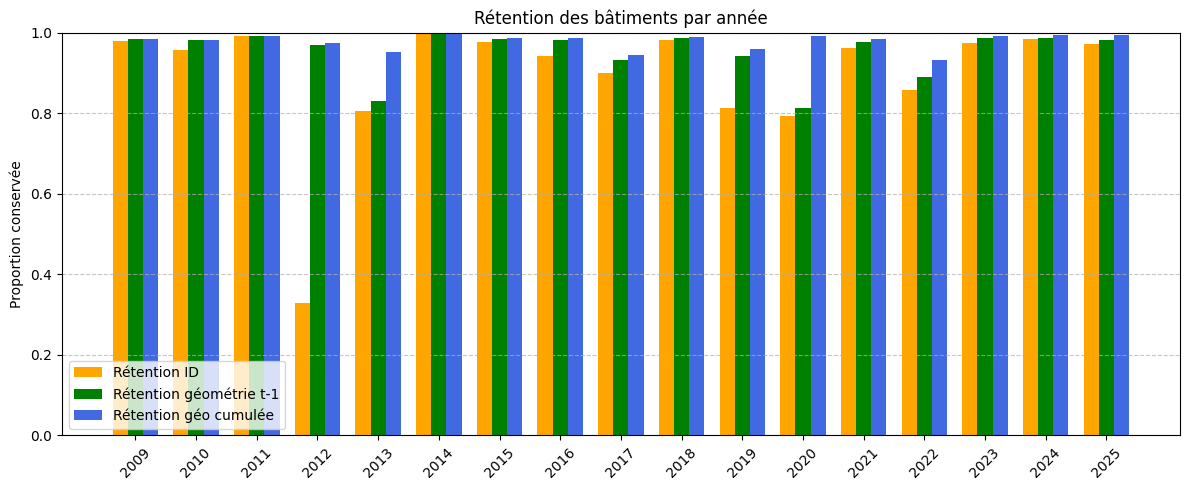

In [17]:
results = []
rayon = 20
use_cumul = True

for i in range(1, len(annees)):
    annee_t = annees[i]
    print(f"Traitement de l'année {annee_t}")
    annee_prev = annees[i-1]
    
    # DataFrames pour l'année t et t-1
    gdf_t = gdf[gdf['Annee'] == annee_t].copy()
    gdf_prev = gdf[gdf['Annee'] == annee_prev].copy()
    gdf_all_prev = gdf[gdf['Annee'] < annee_t].copy()  # toutes les années < t

    #Rétention par ID ---
    ids_t = set(gdf_t['ID'])
    ids_prev = set(gdf_prev['ID'])
    retention_id = len(ids_t & ids_prev) / len(ids_t) if ids_t else None

    #Rétention géographique année précédente ---
    sindex_prev = gdf_prev.sindex
    count_geo_prev = 0
    for geom in gdf_t.geometry:
        candidates = list(sindex_prev.intersection(geom.buffer(rayon).bounds))
        possible_matches = gdf_prev.iloc[candidates]
        if any(possible_matches.distance(geom) <= rayon):
            count_geo_prev += 1
    retention_geo_prev = count_geo_prev / len(gdf_t) if len(gdf_t) > 0 else None

    #rétention géo cumulée (EN OPTION)
    if use_cumul:
        gdf_all_prev = gdf[gdf['Annee'] < annee_t].copy()
        sindex_all_prev = gdf_all_prev.sindex

        count_geo_cumul = 0
        for geom in gdf_t.geometry:
            candidates = list(sindex_all_prev.intersection(geom.buffer(rayon).bounds))
            possible_matches = gdf_all_prev.iloc[candidates]
            if any(possible_matches.distance(geom) <= rayon):
                count_geo_cumul += 1

        retention_geo_cumul = count_geo_cumul / len(gdf_t) if len(gdf_t) > 0 else None
    else:
        retention_geo_cumul = None

    results.append({
        'Annee': annee_t,
        'Rétention_ID_t-1': retention_id,
        'Rétention_geo_t-1': retention_geo_prev,
        'Rétention_geo_cumul': retention_geo_cumul
    })

df_retention_inverse = pd.DataFrame(results)
print(df_retention_inverse)


#plot
df_plot = df_retention_inverse.copy()
x = range(len(df_plot))
width = 0.25
plt.figure(figsize=(12,5))
plt.bar([i - width for i in x], df_plot['Rétention_ID_t-1'], width=width, label='Rétention ID', color='orange')
plt.bar(x, df_plot['Rétention_geo_t-1'], width=width, label='Rétention géométrie t-1', color='green')
plt.bar([i + width for i in x], df_plot['Rétention_geo_cumul'].fillna(0), width=width, color='royalblue', label='Rétention géo cumulée')
plt.xticks(x, df_plot['Annee'], rotation=45)
plt.ylabel("Proportion conservée")
plt.ylim(0,1)
plt.title("Rétention des bâtiments par année")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


In [154]:
ann = 2023
dep_target = 62
rayon = 30

# Bâtiments existants avant l'année cible
gdf_all_prev = gdf[gdf['Annee'] < ann]

# Bâtiments de l'année cible dans le département
gdf_ann = gdf[(gdf['Dep']==dep_target) & (gdf['Annee']==ann)].copy()

# IDs déjà présents
ids_prev = set(gdf_all_prev['ID'])

# Spatial index pour l'année précédente
sindex_prev = gdf_all_prev.sindex

# Listes pour les deux catégories
new_loc_geoms = []
new_loc_origins = []

new_id_geoms = []
new_id_origins = []

new_datecreat_loc = []
new_datemaj_loc = []

new_datecreat_id = []
new_datemaj_id = []

for idx, row in gdf_ann.iterrows():
    geom = row.geometry
    id_curr = row.ID

    # On ne garde que les nouveaux IDs
    if id_curr not in ids_prev:
        # Cherche les bâtiments proches
        candidates_idx = list(sindex_prev.intersection(geom.buffer(rayon).bounds))
        possible = gdf_all_prev.iloc[candidates_idx]

        # Vérifie présence de bâtiments proches
        is_near = any(possible.distance(geom) <= rayon)

        if is_near:
            # Type 2 : nouvel ID proche d'un bâtiment précédent
            new_id_geoms.append(geom.centroid)
            new_id_origins.append(row["ORIGIN_BAT"])
            new_datecreat_id.append(row["DATE_CREAT"])
            new_datemaj_id.append(row["DATE_MAJ"])
        else:
            # Type 1 : nouvelle localisation (aucun bâtiment proche)
            new_loc_geoms.append(geom.centroid)
            new_loc_origins.append(row["ORIGIN_BAT"])
            new_datecreat_loc.append(row["DATE_CREAT"])
            new_datemaj_loc.append(row["DATE_MAJ"])

# --- Conversion en WGS84 pour Google Maps (latitude, longitude) ---
l = 40  # nombre de points à afficher

gdf_new_loc = gpd.GeoDataFrame({
    "ORIGIN_BAT": new_loc_origins[:l],
    "geometry": new_loc_geoms[:l],
    "DATE_CREAT": new_datecreat_loc[:l],
    "DATE_MAJ": new_datemaj_loc[:l]
}, crs=2154).to_crs(4326)

gdf_new_id = gpd.GeoDataFrame({
    "ORIGIN_BAT": new_id_origins[:l],
    "geometry": new_id_geoms[:l],
    "DATE_CREAT": new_datecreat_id[:l],
    "DATE_MAJ": new_datemaj_id[:l]
}, crs=2154).to_crs(4326)

# --- Affichage ---
print(f"\n--- {l} premiers batîments sur de nouvelles localisations (len : {len(new_loc_geoms)})")
for idx, row in gdf_new_loc.iterrows():
    print(f"{row.geometry.y} {row.geometry.x}, ORIGIN_BAT: {row.ORIGIN_BAT}, "
          f"DATE_CREAT:{row.DATE_CREAT}, DATE_MAJ:{row.DATE_MAJ}")

print(f"\n--- {l} premières extensions (nouvel ID sur une ancienne localisation) (len : {len(new_id_geoms)})")
for idx, row in gdf_new_id.iterrows():
    print(f"{row.geometry.y} {row.geometry.x}, ORIGIN_BAT: {row.ORIGIN_BAT}, "
          f"DATE_CREAT:{row.DATE_CREAT}, DATE_MAJ:{row.DATE_MAJ}")



--- 40 premiers batîments sur de nouvelles localisations (len : 38)
50.71342759773784 2.0324277802178567, ORIGIN_BAT: Cadastre, DATE_CREAT:2015-04-23 01:14:44, DATE_MAJ:2022-03-30 14:56:33
50.71311346231361 2.0319065243610717, ORIGIN_BAT: Cadastre, DATE_CREAT:2015-04-23 01:14:44, DATE_MAJ:2022-03-30 14:56:33
50.93856210527866 1.912434028809514, ORIGIN_BAT: Imagerie aérienne, DATE_CREAT:2022-05-30 17:27:23, DATE_MAJ:None
50.4041153607759 1.6017142306294976, ORIGIN_BAT: Imagerie aérienne, DATE_CREAT:2022-05-30 17:27:23, DATE_MAJ:None
50.19846762396183 3.2063473652369385, ORIGIN_BAT: Cadastre, DATE_CREAT:2022-06-01 15:05:01, DATE_MAJ:2022-06-24 14:05:14
50.36619239094256 2.390001019820997, ORIGIN_BAT: Cadastre, DATE_CREAT:2015-05-07 10:55:30, DATE_MAJ:2022-06-03 09:48:36
50.33811417182516 3.0428143193977033, ORIGIN_BAT: Imagerie aérienne, DATE_CREAT:2021-11-03 10:47:47, DATE_MAJ:2022-06-13 10:35:52
50.68023439435063 2.8735837631114416, ORIGIN_BAT: Cadastre, DATE_CREAT:2021-11-30 13:50:47

## Sitadel

In [26]:
import os
import pandas as pd
from credentials import s3

path = "Sitadel/autorisations_locaux_2013_oct_2025.csv"
tmp = f"/tmp/{os.path.basename(path)}"

s3.download_file("mgarbe", path, tmp)
df = pd.read_csv(tmp, sep=";")

/tmp/ipykernel_87781/2422871547.py:9: DtypeWarning: Columns (0,2,4,7,11,17,19,20,21,23,29,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tmp, sep=";")


In [46]:
df.columns

Index(['Code de la région du lieu des travaux - Code de la zone',
       'Code de la région du lieu des travaux - Libellé de la zone',
       'Code du département du lieu des travaux - Code de la zone',
       'Code du département du lieu des travaux - Libellé de la zone',
       'Code de la commune du lieu des travaux', 'TYPE_DAU', 'NUM_DAU',
       'ETAT_DAU',
       'Date réelle d'autorisation (PC) ou de non-opposition (DP) initiale',
       'Date réelle d'ouverture de chantier',
       'Date réelle d'achèvement des travaux', 'Année de dépôt de la DAU',
       'Date (mois) de prise en compte (DPC) du premier évènement reçu dans Sitadel (dépôt de la demande ou autorisation)',
       'Date (mois) de prise en compte (DPC) de l'autorisation initiale',
       'Date (mois) de prise en compte (DPC) de l'ouverture du chantier',
       'Date (mois) (DPC) de dernière mise à jour des données',
       'Code d'activité principale de l'établissement d'un demandeur avéré en tant que personne moral

In [27]:
dest_map = {
    "Entrepôt",
    "Industrie",
    "Commerce"
}

patterns = [
    "Surface de plancher de la destination {} existante avant travaux",
    "Surface de plancher de la destination {} nouvelle construite",
    "Surface de plancher de la destination {} issue d'une transformation",
    "Surface de plancher de la destination {} démolie",
    "Surface de plancher de la destination {} transformée"
]

rename_static = [
    "Code du département du lieu des travaux - Code de la zone",
    "Code de la région du lieu des travaux - Code de la zone",
    "Code de la commune du lieu des travaux",
    "Date réelle d'autorisation (PC) ou de non-opposition (DP) initiale",
    "Date réelle d'ouverture de chantier",
    "Date réelle d'achèvement des travaux",
    "Nature du projet déclarée par le demandeur",
    "Indicateur d'extension",
    "Destination principale",
    'Numéro de voie du terrain',
    'Type de voie du terrain',
    'Libellé de la voie du terrain',
    'Lieu-dit du terrain',
    'Localité du terrain',
    'Code postal du terrain',
    'Superficie du terrain'
]

cols_dyn = []
for dest in dest_map:
    for pat in patterns:
        cols_dyn.append(pat.format(dest))

colonnes_a_garder = rename_static + cols_dyn
colonnes_existantes = [c for c in colonnes_a_garder if c in df.columns]

df = df[colonnes_existantes].copy()
df.columns = df.iloc[0].values
df = df.iloc[1:].reset_index(drop=True)

df["DEP_CODE"] = pd.to_numeric(df["DEP_CODE"], errors="coerce").astype("Int64")
df = df[df["DEP_CODE"].notna() & (df["DEP_CODE"] < 96)]
df = df[df["DESTINATION_PRINCIPALE"].isin([4, 6, 8])]

In [48]:
df.columns

Index(['DEP_CODE', 'REG_CODE', 'COMM', 'DATE_REELLE_AUTORISATION',
       'DATE_REELLE_DOC', 'DATE_REELLE_DAACT', 'NATURE_PROJET_DECLAREE',
       'I_EXTENSION', 'DESTINATION_PRINCIPALE', 'ADR_NUM_TER',
       'ADR_TYPEVOIE_TER', 'ADR_LIBVOIE_TER', 'ADR_LIEUDIT_TER',
       'ADR_LOCALITE_TER', 'ADR_CODPOST_TER', 'SUPERFICIE_TERRAIN',
       'SURF_COM_AVANT', 'SURF_COM_CREEE', 'SURF_COM_ISSUE_TRANSFO',
       'SURF_COM_DEMOLIE', 'SURF_COM_TRANSFORMEE', 'SURF_IND_AVANT',
       'SURF_IND_CREEE', 'SURF_IND_ISSUE_TRANSFO', 'SURF_IND_DEMOLIE',
       'SURF_IND_TRANSFORMEE', 'SURF_ENT_AVANT', 'SURF_ENT_CREEE',
       'SURF_ENT_ISSUE_TRANSFO', 'SURF_ENT_DEMOLIE', 'SURF_ENT_TRANSFORMEE'],
      dtype='object')

In [28]:
cols = [f"SURF_{i}_CREEE" for i in ["ENT", "COM", "IND"]]

# Conversion en numérique (int), en forçant les erreurs à NaN
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").astype("Int64")

# Filtre
df1000 = df[
    (df[cols[0]] > 1000) |
    (df[cols[1]] > 1000) |
    (df[cols[2]] > 1000)
]

len(df1000)


29157

In [29]:
df1000["ADR_CODPOST_TER"] = (
    pd.to_numeric(df1000["ADR_CODPOST_TER"], errors="coerce")  # convertir en float/int
    .astype("Int64")                                           # vrai entier nullable
    .astype(str)                                               # convertir en string
    .str.zfill(5)                                              # forcer à 5 caractères avec zéro devant
)

/tmp/ipykernel_87781/2224525891.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1000["ADR_CODPOST_TER"] = (


In [30]:
(df1000['DATE_REELLE_DAACT'].isna() & df1000['DATE_REELLE_DOC'].isna()).sum()

np.int64(10656)

/tmp/ipykernel_87781/1887685171.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1000["DPC_year"] = pd.to_datetime(


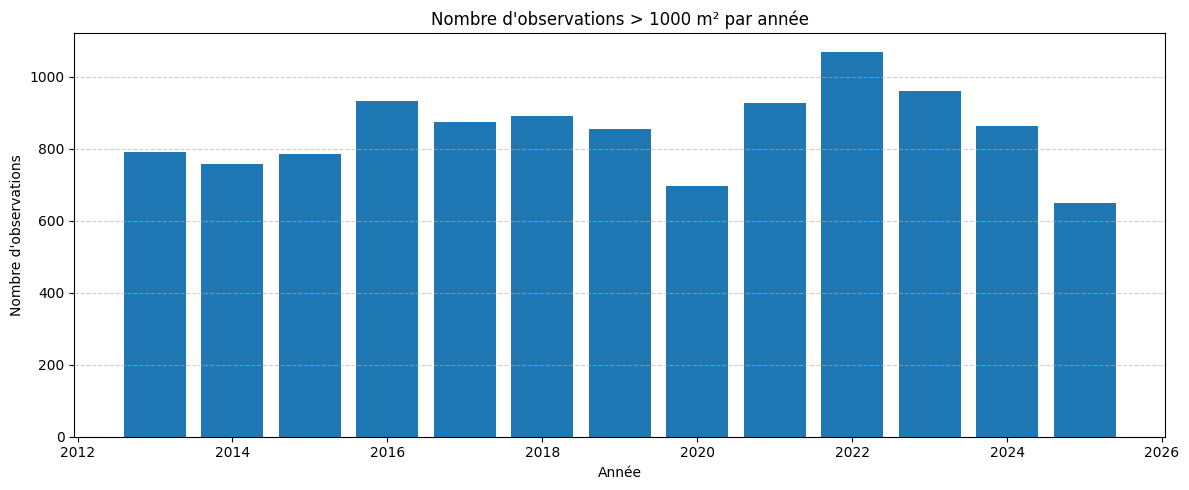

In [18]:
# Convertir en datetime puis extraire l'année
df1000["DPC_year"] = pd.to_datetime(
    df1000["DATE_REELLE_AUTORISATION"],
    errors="coerce"
).dt.year

# Regrouper par année
counts_year = df1000.groupby("DPC_year").size().sort_index()

# Plot en barres
plt.figure(figsize=(12,5))
plt.bar(counts_year.index, counts_year.values)
plt.title("Nombre d'observations > 1000 m² par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'observations")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [19]:
counts_dep = df1000.groupby('DEP_CODE').size().sort_values(ascending=False)

print("Top 10 départements :")
print(counts_dep.head(10))

Top 10 départements :
DEP_CODE
59    1226
44     893
62     822
33     799
69     784
35     719
85     710
67     701
31     694
13     688
dtype: int64


In [22]:
df1000[['DEP_CODE','ADR_NUM_TER', 'ADR_TYPEVOIE_TER', 'ADR_LIBVOIE_TER', 'ADR_LIEUDIT_TER','ADR_LOCALITE_TER', 'ADR_CODPOST_TER']]

,DEP_CODE,ADR_NUM_TER,ADR_TYPEVOIE_TER,ADR_LIBVOIE_TER,ADR_LIEUDIT_TER,ADR_LOCALITE_TER,ADR_CODPOST_TER
8224,2,NaN,NaN,RUE GEORGES BRASSENS,NaN,ATHIES SOUS LAON,02840
8226,2,NaN,RUE,GEORGES BRASSENS LES MINIM,NaN,ATHIES-SOUS-LAON,02840
8294,2,NaN,NaN,ZAC DU GRIFFON,NaN,BARENTON-BUGNY,02000
8297,2,NaN,NaN,RUE JAMES WATT,NaN,BARENTON-BUGNY,02000
8298,2,730,NaN,RUE JAMES WATT,NaN,BARENTON-BUGNY,02000
...,...,...,...,...,...,...,...
775179,95,ILOT,NaN,AVENUE DE L'EUROPE ZAC DES,NaN,VILLIERS-LE-BEL,95400
775188,95,NaN,NaN,AVENUE DE L'EUROPE,ZAC DES TISSONVILLIERS III - ILOT H2,VILLIERS-LE-BEL,95400
775193,95,16-18,NaN,AVENUE DE L'EUROPE,NaN,VILLIERS-LE-BEL,95400
775195,95,13 A,NaN,AVENUE DE L'EUROPE,NaN,VILLIERS-LE-BEL,95400


In [32]:
temp=df1000.copy()

In [35]:
df1000=temp.copy()

In [36]:
df1000=df1000.head(1000).copy()

In [37]:
import pandas as pd
import requests
import io

#Construire la colonne adresse
df1000["adresse"] = (
    df1000["ADR_NUM_TER"].fillna("").astype(str) + " " +
    df1000["ADR_TYPEVOIE_TER"].fillna("").astype(str) + " " +
    df1000["ADR_LIBVOIE_TER"].fillna("").astype(str) + " " +
    df1000["ADR_LIEUDIT_TER"].fillna("").astype(str) + " " +
    df1000["ADR_LOCALITE_TER"].fillna("").astype(str) + " " +
    df1000["ADR_CODPOST_TER"].fillna("").astype(str)
).str.strip().str.replace(r"\s+", " ", regex=True)


#csv minimal
df_export = df1000[["adresse"]].copy()
csv_bytes = df_export.to_csv(index=False).encode("utf-8")


#appel unique de masse
url = "https://api-adresse.data.gouv.fr/search/csv/"

print("Envoi du CSV à l'API BAN")

response = requests.post(
    url,
    files={"data": ("adresses.csv", csv_bytes, "text/csv")},
    timeout=60
)

print("Réponse reçue, chargement…")

#Récupérer le CSV résultat dans un DataFrame
df1000_BAN = pd.read_csv(io.BytesIO(response.content))


#Renommer les colonnes importantes
df1000_BAN = df1000_BAN.rename(columns={
    "latitude": "lat_BAN",
    "longitude": "lon_BAN",
    "result_score": "score_BAN",
    "result_label": "adresse_BAN",
})

df1000_BAN = df1000_BAN[[
    "adresse",
    "lat_BAN",
    "lon_BAN",
    "score_BAN",
    "adresse_BAN"
]]

#Fusion des résultats sur l’adresse
df1000 = df1000.merge(df1000_BAN, on="adresse", how="left")

print("Géocodage massif terminé.")
print(df1000.head())


Envoi du CSV à l'API BAN


Réponse reçue, chargement…
Géocodage massif terminé.
   DEP_CODE REG_CODE  COMM DATE_REELLE_AUTORISATION DATE_REELLE_DOC  \
0         2       22  2028               02/07/2020             NaN   
1         2       22  2028               22/04/2021      01/12/2021   
2         2       22  2046               23/12/2019      23/04/2020   
3         2       22  2046               23/09/2022             NaN   
4         2       22  2046               27/10/2022      07/11/2022   

  DATE_REELLE_DAACT NATURE_PROJET_DECLAREE I_EXTENSION DESTINATION_PRINCIPALE  \
0               NaN                      1        True                      6   
1               NaN                      1       False                      8   
2        15/02/2021                      1       False                      6   
3               NaN                      1       False                      8   
4        04/07/2023                      1       False                      8   

  ADR_NUM_TER  ... SURF_COM_AVANT

In [38]:
df1000[df1000['lat_BAN'].isna()]

,DEP_CODE,REG_CODE,COMM,DATE_REELLE_AUTORISATION,DATE_REELLE_DOC,DATE_REELLE_DAACT,NATURE_PROJET_DECLAREE,I_EXTENSION,DESTINATION_PRINCIPALE,ADR_NUM_TER,...,SURF_COM_AVANT,SURF_COM_CREEE,SURF_COM_ISSUE_TRANSFO,SURF_COM_DEMOLIE,SURF_COM_TRANSFORMEE,adresse,lat_BAN,lon_BAN,score_BAN,adresse_BAN
463,3,83,3236,21/07/2021,01/09/2021,30/09/2022,2,True,6,NaN,...,0,0,0,0,0,ZI DU COQUET SAINT-GERMAIN-DES-FOSSES 03260,NaN,NaN,NaN,NaN
483,3,83,3262,22/05/2018,08/12/2018,24/07/2019,1,False,4,NaN,...,0,2734,0,0,0,"""""LE RIF"""" ROUTE DE PARIS SAINT-VICTOR 03410",NaN,NaN,NaN,NaN
540,4,93,4035,15/01/2016,NaN,NaN,1,False,4,5079,...,0,15000,0,0,0,5079 LE COUVENT BRUNET 00000,NaN,NaN,NaN,NaN
551,4,93,4112,13/09/2013,NaN,NaN,1,False,8,NaN,...,0,0,0,0,0,RUE JEAN PERRIN ZI SAINT MAURICE MANOSQUE 04100,NaN,NaN,NaN,NaN
742,6,93,6069,12/12/2013,02/03/2015,NaN,1,False,8,NaN,...,0,0,0,0,0,CHEMIN DE L'ORME - AROMA G LOT 3 ET 9 GRASSE 0...,NaN,NaN,NaN,NaN
749,6,93,6069,19/05/2016,NaN,NaN,2,False,4,NaN,...,1064,1931,0,0,0,28 ROUTE DE VALBONNE SUPER U PLASCASSIER GRASS...,NaN,NaN,NaN,NaN
799,6,93,6088,17/07/2019,30/01/2023,NaN,1,False,4,NaN,...,0,1949,0,0,0,AV SIMONE VEIL ZAC MERIDIA SECTEUR 3 NICE 06200,NaN,NaN,NaN,NaN
1117,8,21,8362,24/06/2025,NaN,NaN,2,True,8,NaN,...,0,0,0,0,0,RUE HENRI BAUCHET - ZI DE RETHEL CEDEX 08303,NaN,NaN,NaN,NaN


In [ ]:
df1000[df1000['lat_BAN'].isna()]

,DEP_CODE,REG_CODE,COMM,DATE_REELLE_AUTORISATION,DATE_REELLE_DOC,DATE_REELLE_DAACT,NATURE_PROJET_DECLAREE,I_EXTENSION,DESTINATION_PRINCIPALE,ADR_NUM_TER,...,SURF_COM_AVANT,SURF_COM_CREEE,SURF_COM_ISSUE_TRANSFO,SURF_COM_DEMOLIE,SURF_COM_TRANSFORMEE,adresse,lat_BAN,lon_BAN,score_BAN,adresse_BAN
463,3,83,3236,21/07/2021,01/09/2021,30/09/2022,2,True,6,NaN,...,0,0,0,0,0,ZI DU COQUET SAINT-GERMAIN-DES-FOSSES 03260,NaN,NaN,NaN,NaN
483,3,83,3262,22/05/2018,08/12/2018,24/07/2019,1,False,4,NaN,...,0,2734,0,0,0,"""""LE RIF"""" ROUTE DE PARIS SAINT-VICTOR 03410",NaN,NaN,NaN,NaN
540,4,93,4035,15/01/2016,NaN,NaN,1,False,4,5079,...,0,15000,0,0,0,5079 LE COUVENT BRUNET 00000,NaN,NaN,NaN,NaN
551,4,93,4112,13/09/2013,NaN,NaN,1,False,8,NaN,...,0,0,0,0,0,RUE JEAN PERRIN ZI SAINT MAURICE MANOSQUE 04100,NaN,NaN,NaN,NaN
742,6,93,6069,12/12/2013,02/03/2015,NaN,1,False,8,NaN,...,0,0,0,0,0,CHEMIN DE L'ORME - AROMA G LOT 3 ET 9 GRASSE 0...,NaN,NaN,NaN,NaN
749,6,93,6069,19/05/2016,NaN,NaN,2,False,4,NaN,...,1064,1931,0,0,0,28 ROUTE DE VALBONNE SUPER U PLASCASSIER GRASS...,NaN,NaN,NaN,NaN
799,6,93,6088,17/07/2019,30/01/2023,NaN,1,False,4,NaN,...,0,1949,0,0,0,AV SIMONE VEIL ZAC MERIDIA SECTEUR 3 NICE 06200,NaN,NaN,NaN,NaN
1117,8,21,8362,24/06/2025,NaN,NaN,2,True,8,NaN,...,0,0,0,0,0,RUE HENRI BAUCHET - ZI DE RETHEL CEDEX 08303,NaN,NaN,NaN,NaN


In [31]:
import pandas as pd
import requests
import time

def geocode_adresse_ban(adresse):
    url = "https://api-adresse.data.gouv.fr/search/"
    params = {"q": adresse, "limit": 1}

    for attempt in range(5):  # Jusqu'à 5 tentatives
        try:
            r = requests.get(url, params=params, timeout=5)

            # --- Gestion du dépassement de quota ---
            if r.status_code == 429:
                wait = int(r.headers.get("retry-after", 5))
                print(f"Limite appel API, {wait}s…")
                time.sleep(wait)
                continue

            r.raise_for_status()
            data = r.json()

            if data["features"]:
                coords = data["features"][0]["geometry"]["coordinates"]
                return pd.Series({"lon": coords[0], "lat": coords[1]})
            else:
                return pd.Series({"lon": None, "lat": None})

        except Exception as e:
            print(f"Erreur réseau, nouvelle tentative ({attempt+1}/5)…")
            time.sleep(1)

    return pd.Series({"lon": None, "lat": None})



# Construire la colonne adresse
df1000["adresse"] = (
    df1000["ADR_NUM_TER"].fillna("").astype(str) + " " +
    df1000["ADR_TYPEVOIE_TER"].fillna("").astype(str) + " " +
    df1000["ADR_LIBVOIE_TER"].fillna("").astype(str) + " " +
    df1000["ADR_LIEUDIT_TER"].fillna("").astype(str) + " " +
    df1000["ADR_LOCALITE_TER"].fillna("").astype(str) + " " +
    df1000["ADR_CODPOST_TER"].fillna("").astype(str)
).str.strip().str.replace(r"\s+", " ", regex=True)

results = []

for i, adresse in enumerate(df1000["adresse"]):
    if i % 500 == 0:
        print(f"Géocodage {i}/{len(df1000)}")

    # Géocodage sécurisé
    res = geocode_adresse_ban(adresse)
    results.append(res)

    # --- Rate limit BAN : 45/s ---
    time.sleep(1/45)  

df_coords = pd.DataFrame(results)
df1000_geo = pd.concat([df1000.reset_index(drop=True), df_coords], axis=1)


/tmp/ipykernel_76302/26472196.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1000["adresse"] = (


Géocodage 0/100


In [64]:
df1000_BAN['lat'].isna().sum()

# Conversion en datetime (au cas où la colonne serait string)
df1000_BAN["DATE_REELLE_AUTORISATION"] = pd.to_datetime(df1000_BAN["DATE_REELLE_AUTORISATION"], errors="coerce", dayfirst=True)

# Extraire l'année
df1000_BAN["Annee"] = df1000_BAN["DATE_REELLE_AUTORISATION"].dt.year

In [65]:
df1000_BAN['DATE_REELLE_AUTORISATION'].isna().sum()

np.int64(0)

In [66]:
temp=df1000_BAN[df1000_BAN['Annee']<2022].copy()

In [67]:
gdf_temp=gdf[gdf["Annee"]==2025]

In [85]:
import geopandas as gpd
from shapely.geometry import Point

# Transformer temp en GeoDataFrame
gdf_temp_points = gpd.GeoDataFrame(
    temp,
    geometry=gpd.points_from_xy(temp["lon"], temp["lat"]),
    crs="EPSG:4326"
)

# Ajouter coordonnées de gdf_temp avant tout
gdf_temp["coord_gdf"] = gdf_temp.geometry.centroid.to_crs(epsg=4326).apply(
    lambda p: f"{p.y:.6f} {p.x:.6f}" if p else None
)
# Projetter en métrique pour buffer
gdf_temp_points = gdf_temp_points.to_crs(epsg=2154)
gdf_temp = gdf_temp.to_crs(epsg=2154)

# Buffer pour tolérance
tolerance_m = 50
gdf_temp_points["geometry_buffer"] = gdf_temp_points.geometry.buffer(tolerance_m)

# Spatial join
joined = gpd.sjoin(
    gdf_temp_points.set_geometry("geometry_buffer"),
    gdf_temp,
    how="left",
    predicate="intersects"
)

# Repasser en WGS84 pour temp
joined = joined.to_crs(epsg=4326)

# Colonnes coordonnées
joined["coord_temp"] = joined["lat"].astype(str) + " " + joined["lon"].astype(str)

# coord_gdf déjà calculé dans gdf_temp et propagé via sjoin
# vérifier les premières lignes
print(joined[["coord_temp", "coord_gdf"]].head())



           coord_temp           coord_gdf
0  49.574288 3.675562                 NaN
1  49.574288 3.675562                 NaN
2   49.63254 3.647644                 NaN
7  49.037903 3.630227                 NaN
8  49.661217 3.344721  49.660711 3.344587


In [89]:
oined[~(joined["DATE_CREAT"].isna())]

NameError: name 'oined' is not defined

In [68]:
%run Sitadel2_traitement_1auto.py

/home/onyxia/work/projet3A/Sitadel2_traitement_1auto.py:18: DtypeWarning: Columns (0,2,4,7,11,17,19,20,21,23,29,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tmp, sep=";")
/home/onyxia/work/projet3A/Sitadel2_traitement_1auto.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1000["ANNEE_REELLE_AUTORISATION"] = pd.to_datetime(


Lancement de la requête BAN
df_ban
                                                 adresse    lat_BAN   lon_BAN  \
6923                       133 RUE LECOCQ 33000 BORDEAUX  44.833275 -0.588851   
8344                   181 RUE DE CHATILLON 35000 RENNES  48.088886 -1.672032   
25320              282 RUE FRANCOIS PERRIN 87000 LIMOGES  45.824679  1.227735   
602               606 BOULEVARD DU MERCANTOUR 06200 NICE  43.727756  7.185797   
23155              501 CHAUSSEE JULES FERRY 80090 AMIENS  49.877572  2.341606   
...                                                  ...        ...       ...   
26092  RUE CLEMENT ADER LOT A4-13-1 ZAC DE LA CLE DE ...        NaN       NaN   
26200        RUE HENRI FABRE -PRES D'ANTONY 0<NA> ANTONY        NaN       NaN   
26427  ""LES BRUYERES"" RUE DU PAVE 93290 TREMBLAY-EN...        NaN       NaN   
26430  ZONE DE SERVICE - AIRES AE AERPORT PARIS-CHARL...        NaN       NaN   
26723           ZAC DU PARC DES TULIPES NO 95500 GONESSE        NaN       

In [69]:
temp=df1000[df1000['adresse'].str.contains(r'(parc|\bzi|\bzac|\bza)', case=False, na=False)]
print(f'{len(temp)}/{len(df1000)} labels "zone" dans les adresses')
df1000[
    df1000['adresse'].str.contains(r'(parc|\bzi|\bzac|\bza)', case=False, na=False) &  # Recherche sans \b pour trouver "parc" dans "LOGICPARC"
    df1000['adresse_BAN'].str.contains(r'(parc d|zi|zac|za|zone)', case=False, na=False)
][["adresse","adresse_BAN","score_BAN","SURF_ENT_CREEE","SURF_COM_CREEE",
     "SURF_IND_CREEE","DATE_REELLE_AUTORISATION","DATE_REELLE_DOC",
     "DATE_REELLE_DAACT"]]

/tmp/ipykernel_170788/3393787453.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  temp=df1000[df1000['adresse'].str.contains(r'(parc|\bzi|\bzac|\bza)', case=False, na=False)]
/tmp/ipykernel_170788/3393787453.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df1000['adresse'].str.contains(r'(parc|\bzi|\bzac|\bza)', case=False, na=False) &  # Recherche sans \b pour trouver "parc" dans "LOGICPARC"
/tmp/ipykernel_170788/3393787453.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df1000['adresse_BAN'].str.contains(r'(parc d|zi|zac|za|zone)', case=False, na=False)


4512/26937 labels "zone" dans les adresses


,adresse,adresse_BAN,score_BAN,SURF_ENT_CREEE,SURF_COM_CREEE,SURF_IND_CREEE,DATE_REELLE_AUTORISATION,DATE_REELLE_DOC,DATE_REELLE_DAACT
10,ZID DE L'OMOIS 02400 BEZU-SAINT-GERMAIN,rue du marchis zid de l omois 02400 Épaux-Bézu,0.441453,60759,0,0,26/10/2022,NaN,NaN
11,ZI DE L'OMOIS 02400 BEZU-SAINT-GERMAIN,ZI de l'Omois 02400 Bézu-Saint-Germain,0.938619,1190,0,0,20/01/2023,NaN,NaN
26,ZI DE LA MOISERIE 02400 CHATEAU-THIERRY,ZI de l'Omois 02400 Château-Thierry,0.691237,3675,0,0,25/09/2015,05/03/2016,NaN
54,ZI DE L OMOIS 02400 EPAUX-BEZU,ZI de l'Omois 02400 Épaux-Bézu,0.935871,12176,0,0,29/04/2014,16/10/2015,NaN
55,ZI DE L OMOIS 02400 PAUX-BEZU,ZI de l'Omois 02400 Épaux-Bézu,0.844962,8253,0,0,07/02/2015,NaN,NaN
...,...,...,...,...,...,...,...,...,...
26722,CD N_E4- ZI HORIZON DUD 34110 FRONTIGNAN,ZI la Bordelaise 34110 Frontignan,0.382643,0,0,2220,11/09/2015,11/10/2015,12/11/2015
26788,ZA LA FORET 72470 CHAMPAGNE,ZA La Champagne 45420 Bonny-sur-Loire,0.531860,1155,0,0,09/03/2016,09/03/2016,28/10/2016
26876,PARC D'ACTIVITES OXYLANE - ST CLEMENT DE RIVIERE,ZA Parc Activite Clément Ader 64510 Bordes,0.452547,0,1304,0,14/09/2016,NaN,NaN
26890,ECO PARC 45210 FERRIERES,Parc de Ferrieres 77164 Ferrières-en-Brie,0.490275,116093,0,0,06/07/2022,16/01/2023,NaN


In [71]:
df1000[
    df1000['adresse'].str.contains(r'(parc|\bzi|\bzac|\bza)', case=False, na=False) &  # Recherche de "parc", "zi", "zac", "za"
    ~df1000['adresse_BAN'].str.contains(r'(parc d|zi|zac|za|zone)', case=False, na=False) &  # Exclut les "parc d", "zi", "zac", "za" dans adresse_BAN
    ~(df1000['adresse'].str.contains(r'\brue\b', case=False, na=False) & df1000['adresse_BAN'].str.contains(r'\brue\b', case=False, na=False))  # Exclut les observations avec "rue" dans les deux colonnes
][["adresse","adresse_BAN","score_BAN","SURF_ENT_CREEE","SURF_COM_CREEE",
     "SURF_IND_CREEE","DATE_REELLE_AUTORISATION","DATE_REELLE_DOC",
     "DATE_REELLE_DAACT"]]

/tmp/ipykernel_170788/1030228959.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df1000['adresse'].str.contains(r'(parc|\bzi|\bzac|\bza)', case=False, na=False) &  # Recherche de "parc", "zi", "zac", "za"
/tmp/ipykernel_170788/1030228959.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~df1000['adresse_BAN'].str.contains(r'(parc d|zi|zac|za|zone)', case=False, na=False) &  # Exclut les "parc d", "zi", "zac", "za" dans adresse_BAN


,adresse,adresse_BAN,score_BAN,SURF_ENT_CREEE,SURF_COM_CREEE,SURF_IND_CREEE,DATE_REELLE_AUTORISATION,DATE_REELLE_DOC,DATE_REELLE_DAACT
2,ZAC DU GRIFFON 02000 BARENTON-BUGNY,Barenton-Bugny,0.531783,0,0,20461,23/12/2019,23/04/2020,15/02/2021
25,ZIR DE LA MOISERIE 02400 CHATEAU-THIERRY,Rue de la Prairie 02400 Château-Thierry,0.667919,1065,4356,0,27/05/2014,NaN,NaN
27,PARC DU CITELIUM 02400 CHATEAU-THIERRY,Rue du Parc 02400 Château-Thierry,0.672716,0,1300,0,29/11/2016,29/06/2017,NaN
46,ZACDU PLATEAU DE COURMELLE 02200 COURMELLES,La Plai du Mont de Courmel 02200 Courmelles,0.564045,0,0,1078,20/10/2015,NaN,NaN
47,ZAC PLATEAU DE COURMELLES PLOI 02200 COURMELLES,La Plai du Mont de Courmel 02200 Courmelles,0.526731,0,0,1078,15/10/2014,07/04/2015,NaN
...,...,...,...,...,...,...,...,...,...
26713,ZA VOIE ROMAINE - RUE DE 27370 LE THUIT DE L'O...,Voie Romaine 27370 Le Thuit de l'Oison,0.759805,0,2553,0,07/07/2022,NaN,NaN
26714,VOIE DE L'OREE-ZAC DU PARC 27100 VAL-DE-REUIL,Voie de l’Orée 27100 Val-de-Reuil,0.709667,14007,0,0,18/12/2017,NaN,NaN
26781,CHEMI DES VOYEUX - ZI 62140 MARCONNELLE,Chemin des Voyeux 62140 Marconnelle,0.800446,0,0,2882,01/02/2022,01/04/2022,28/02/2023
26784,ECOPARC BASSE ZORN 67720 HOERDT,Impasse des Roses 67720 Hœrdt,0.411254,1112,0,0,15/05/2025,NaN,NaN


In [52]:
df1000[df1000["adresse"].str.contains("PARC", case=False, na=False)][
    ["adresse","adresse_BAN","score_BAN","SURF_ENT_CREEE","SURF_COM_CREEE",
     "SURF_IND_CREEE","DATE_REELLE_AUTORISATION","DATE_REELLE_DOC",
     "DATE_REELLE_DAACT"]
].head(30)

,adresse,adresse_BAN,score_BAN,SURF_ENT_CREEE,SURF_COM_CREEE,SURF_IND_CREEE,DATE_REELLE_AUTORISATION,DATE_REELLE_DOC,DATE_REELLE_DAACT
27,PARC DU CITELIUM 02400 CHATEAU-THIERRY,Rue du Parc 02400 Château-Thierry,0.672716,0,1300,0,29/11/2016,29/06/2017,NaN
141,PARC D'ACTIVITES DES AUTOR 02100 SAINT-QUENTIN,Rue des Patriotes 02100 Saint-Quentin,0.518499,67144,0,0,29/08/2017,22/08/2022,NaN
142,PARC DES AUTOROUTES 02100 SAINT-QUENTIN,Rue des Patriotes 02100 Saint-Quentin,0.586197,3990,0,0,10/08/2017,18/10/2017,07/09/2018
145,PARC D'ACTIVITES DES AUTOR 02100 SAINT-QUENTIN,Rue des Patriotes 02100 Saint-Quentin,0.518499,0,0,6520,11/01/2019,18/01/2019,18/08/2020
147,PARC D'ACTIVITES DES AUTOR 02100 SAINT-QUENTIN,Rue des Patriotes 02100 Saint-Quentin,0.518499,0,0,6510,04/05/2020,10/06/2020,NaN
150,RUE GEORGES CHARPAK PARC DES AUTOROUTES 02100 ...,Rue Georges Charpak 02100 Saint-Quentin,0.649515,0,0,13701,12/05/2022,NaN,NaN
151,RUE GEORGES CHARPAK ZAC DU PARC D'ACTIVITE DES...,Rue Georges Charpak 02100 Saint-Quentin,0.508449,9636,0,0,22/03/2022,28/08/2023,02/09/2024
152,PARC DES AUTOROUTES - GEOR 02100 SAINT-QUENTIN,Rue des Patriotes 02100 Saint-Quentin,0.535982,0,0,28375,15/03/2022,NaN,NaN
153,PARC DES AUTOROUTES 02100 SAINT-QUENTIN,Rue des Patriotes 02100 Saint-Quentin,0.586197,583,0,7272,23/09/2022,20/06/2023,NaN
302,CHEM DU BLANCHEROT-BIOPARC LAVAURE 03270 HAUTE...,ZA du Bioparc 03270 Hauterive,0.493801,416,0,1021,07/08/2014,NaN,NaN


## Clustering

In [5]:
plot_DB_epsilon(gdf,2008,4,1,301,20)

Progress: 13/15 | eps : 241, clusters : 0.680, isolés : 0.320


KeyboardInterrupt: 

In [25]:
#######
####### ON FIXE LES PARAMETRES : A MODIFIER
#######

epsilon_petit = 50
epsilon_grand = 1000
m_sample = 4

On segmente par groupes de 20 départements. On fait tout le process et on stocke. Puis à la fin on aggrège selon tous les départements. Pour les proportions, l'aggrégation se fait à la fin.

In [26]:
####Fonction meta cluster : test en local avant de mettre dans fonctions

import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.cluster import DBSCAN

def gdf_meta_DBSCAN(gdf: gpd.GeoDataFrame,
                    annee: int,
                    eps1: float,
                    eps2: float,
                    min_sample: int = 4):
    # 1) Filtre année
    gdf_annee = gdf[gdf["Annee"] == annee].copy()
    if len(gdf_annee) == 0:
        gdf_annee["centroid"] = pd.Series(dtype="object")
        gdf_annee["id_cluster"] = pd.Series(dtype="int64")
        gdf_annee["id_meta_cluster"] = pd.Series(dtype="int64")
        return gdf_annee, dict(n_clusters_lvl1=0, n_noise_lvl1=0,
                               n_meta_clusters=0, n_meta_noise=0)

    # 2) CRS métrique
    if gdf_annee.crs is None or not gdf_annee.crs.is_projected:
        gdf_annee = gdf_annee.to_crs(2154)

    # 3) Centroids
    gdf_annee["centroid"] = gdf_annee.geometry.centroid
    coords = np.column_stack([gdf_annee["centroid"].x.values,
                              gdf_annee["centroid"].y.values])

    # 4) DBSCAN niveau 1
    db1 = DBSCAN(eps=eps1, min_samples=min_sample)
    labels1 = db1.fit_predict(coords)
    gdf_annee["id_cluster"] = labels1.astype(int)

    n_clusters_lvl1 = int(len(set(labels1)) - (1 if -1 in labels1 else 0))
    n_noise_lvl1 = int(np.sum(labels1 == -1))

    # 5) Barycentres (clusters != -1)
    mask_clusters = (gdf_annee["id_cluster"].values != -1)  # <-- bool np.array
    if mask_clusters.any():
        df_centroids = (
            gdf_annee.loc[mask_clusters, ["id_cluster", "centroid"]]
            .assign(x=lambda d: d["centroid"].x,
                    y=lambda d: d["centroid"].y)
            .groupby("id_cluster", as_index=False)[["x", "y"]].mean()
        )

        # 6) DBSCAN niveau 2 sur barycentres (ceux des 

        bary_coords = np.column_stack([df_centroids["x"].values, df_centroids["y"].values])
        db2 = DBSCAN(eps=eps2, min_samples=min_sample)
        labels2 = db2.fit_predict(bary_coords)

        # 7) Remappage des labels de méta-clusters en 0..K-1 (en conservant -1)
        uniq = sorted([l for l in set(labels2) if l != -1])
        remap = {old: new for new, old in enumerate(uniq)}
        meta_labels = pd.Series(labels2).map(remap).fillna(-1).astype(int).to_numpy()

        # 8) Propagation aux entités d'origine
        meta_map = dict(zip(df_centroids["id_cluster"].astype(int).tolist(),
                            meta_labels.tolist()))
        gdf_annee["id_meta_cluster"] = gdf_annee["id_cluster"].map(meta_map).fillna(-1).astype(int)

        # Les bruits niveau 1 restent -1 (sans .loc avec ~mask ; approche .where)
        gdf_annee["id_meta_cluster"] = gdf_annee["id_meta_cluster"].where(
            gdf_annee["id_cluster"] != -1, -1
        ).astype(int)

        n_meta_clusters = int(len(uniq))
        n_meta_noise = int(np.sum(labels2 == -1))
    else:
        # Aucun cluster niveau 1
        gdf_annee["id_meta_cluster"] = -1
        n_meta_clusters, n_meta_noise = 0, 0

    # (optionnel) logs
    print(f"[Niveau 1] Clusters: {n_clusters_lvl1} | Bruit: {n_noise_lvl1}")
    print(f"[Niveau 2] Méta-clusters: {n_meta_clusters} | Bruit (barycentres): {n_meta_noise}")

    return gdf_annee, dict(
        n_clusters_lvl1=n_clusters_lvl1,
        n_noise_lvl1=n_noise_lvl1,
        n_meta_clusters=n_meta_clusters,
        n_meta_noise=n_meta_noise
    )


        


#### TEST

test , stat = gdf_meta_DBSCAN(gdf,
                    annee =  2008,
                    eps1 =  50,
                    eps2 =  1000,
                    min_sample= 5)

[Niveau 1] Clusters: 1380 | Bruit: 164798
[Niveau 2] Méta-clusters: 26 | Bruit (barycentres): 1104


In [83]:
stat["n_clusters_lvl1"]

8849

In [ ]:
#### département 1 à 20

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_1_20.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf1 = []
nbclust1 = []
nbmeta1 = []
nbisole1 = []
nbconv1 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année
nbbat1 = []
for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf1.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust1.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta1.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole1.append(stat["n_noise_lvl1"])

    ## nb batiments
    nbbat1.append(len(gdf_meta))
    ## nb conv : On verra pour l'implémenter plus tard
    # On commence par merger gdf meta et meta moins1 sur id pour rajouter l'id clu
    gdf_meta_moins1.rename(columns={"id_cluster": "id_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_cluster_moins"]], on="ID", how="left")
    nbconv1.append(len(gdf_meta[(gdf_meta.id_cluster != -1) & (gdf_meta.id_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_cluster_moins == -1]))



In [89]:
#### département 21 à 40

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_21_40.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf2 = []
nbclust2 = []
nbmeta2 = []
nbisole2 = []
nbconv2 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf2.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust2.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta2.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole2.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_cluster": "id_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_cluster_moins"]], on="ID", how="left")
    nbconv2.append(len(gdf_meta[(gdf_meta.id_cluster != -1) & (gdf_meta.id_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_cluster_moins == -1]))

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_21_40.gpkg ...
Chargement réussi (5532961 lignes)
[Niveau 1] Clusters: 10272 | Bruit: 346627
[Niveau 2] Méta-clusters: 403 | Bruit (barycentres): 7110
[Niveau 1] Clusters: 9350 | Bruit: 346752
[Niveau 2] Méta-clusters: 369 | Bruit (barycentres): 6720
[Niveau 1] Clusters: 10927 | Bruit: 345651
[Niveau 2] Méta-clusters: 442 | Bruit (barycentres): 7369
[Niveau 1] Clusters: 10272 | Bruit: 346627
[Niveau 2] Méta-clusters: 403 | Bruit (barycentres): 7110
[Niveau 1] Clusters: 11654 | Bruit: 348889
[Niveau 2] Méta-clusters: 493 | Bruit (barycentres): 7626
[Niveau 1] Clusters: 10927 | Bruit: 345651
[Niveau 2] Méta-clusters: 442 | Bruit (barycentres): 7369
[Niveau 1] Clusters: 11654 | Bruit: 348889
[Niveau 2] Méta-clusters: 493 | Bruit (barycentres): 7626
[Niveau 1] Clusters: 17012 | Bruit: 317328
[Niveau 2] Méta-clusters: 752 | Bruit (barycentres): 9801
[Niveau 1] Clusters: 18189 | Bruit: 309381
[Niveau 2] Méta-clusters: 804 | Bruit (bar

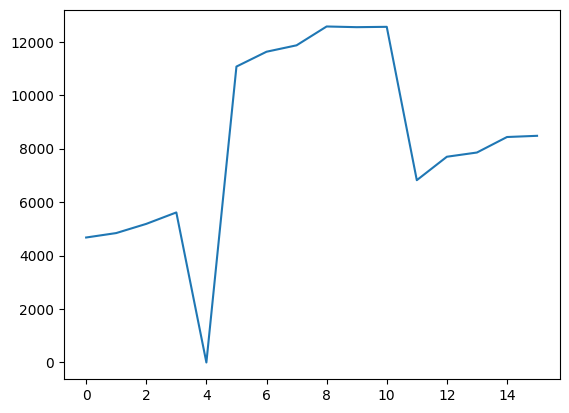

In [93]:
plt.plot(nbclust)

In [94]:
#### département 41 à 60

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_41_60.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf3 = []
nbclust3 = []
nbmeta3 = []
nbisole3 = []
nbconv3 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf3.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust3.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta3.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole3.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_cluster": "id_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_cluster_moins"]], on="ID", how="left")
    nbconv3.append(len(gdf_meta[(gdf_meta.id_cluster != -1) & (gdf_meta.id_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_cluster_moins == -1]))

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_41_60.gpkg ...
Chargement réussi (6183558 lignes)
[Niveau 1] Clusters: 10635 | Bruit: 379440
[Niveau 2] Méta-clusters: 409 | Bruit (barycentres): 7178
[Niveau 1] Clusters: 9976 | Bruit: 381921
[Niveau 2] Méta-clusters: 374 | Bruit (barycentres): 7036
[Niveau 1] Clusters: 11271 | Bruit: 381960
[Niveau 2] Méta-clusters: 417 | Bruit (barycentres): 7689
[Niveau 1] Clusters: 10635 | Bruit: 379440
[Niveau 2] Méta-clusters: 409 | Bruit (barycentres): 7178
[Niveau 1] Clusters: 11310 | Bruit: 378653
[Niveau 2] Méta-clusters: 414 | Bruit (barycentres): 7663
[Niveau 1] Clusters: 11271 | Bruit: 381960
[Niveau 2] Méta-clusters: 417 | Bruit (barycentres): 7689
[Niveau 1] Clusters: 11310 | Bruit: 378653
[Niveau 2] Méta-clusters: 414 | Bruit (barycentres): 7663
[Niveau 1] Clusters: 24365 | Bruit: 331283
[Niveau 2] Méta-clusters: 918 | Bruit (barycentres): 9574
[Niveau 1] Clusters: 24840 | Bruit: 320721
[Niveau 2] Méta-clusters: 943 | Bruit (bar

In [95]:
#### département 61 à 80

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_61_80.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf4 = []
nbclust4 = []
nbmeta4 = []
nbisole4 = []
nbconv4 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf4.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust4.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta4.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole4.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_cluster": "id_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_cluster_moins"]], on="ID", how="left")
    nbconv4.append(len(gdf_meta[(gdf_meta.id_cluster != -1) & (gdf_meta.id_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_cluster_moins == -1]))

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_61_80.gpkg ...
Chargement réussi (5907821 lignes)
[Niveau 1] Clusters: 8397 | Bruit: 322980
[Niveau 2] Méta-clusters: 340 | Bruit (barycentres): 5142
[Niveau 1] Clusters: 7488 | Bruit: 324000
[Niveau 2] Méta-clusters: 293 | Bruit (barycentres): 4935
[Niveau 1] Clusters: 10988 | Bruit: 331479
[Niveau 2] Méta-clusters: 420 | Bruit (barycentres): 6167
[Niveau 1] Clusters: 8397 | Bruit: 322980
[Niveau 2] Méta-clusters: 340 | Bruit (barycentres): 5142
[Niveau 1] Clusters: 14236 | Bruit: 319104
[Niveau 2] Méta-clusters: 575 | Bruit (barycentres): 6576
[Niveau 1] Clusters: 10988 | Bruit: 331479
[Niveau 2] Méta-clusters: 420 | Bruit (barycentres): 6167
[Niveau 1] Clusters: 14236 | Bruit: 319104
[Niveau 2] Méta-clusters: 575 | Bruit (barycentres): 6576
[Niveau 1] Clusters: 18165 | Bruit: 296559
[Niveau 2] Méta-clusters: 781 | Bruit (barycentres): 7387
[Niveau 1] Clusters: 19106 | Bruit: 294409
[Niveau 2] Méta-clusters: 842 | Bruit (baryc

In [205]:
#### département 81 à 99

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf5 = []
nbclust5 = []
nbmeta5 = []
nbisole5 = []
nbconv5 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année
nbbat5 = []

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des indus
    surf5.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust5.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta5.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole5.append(stat["n_noise_lvl1"])

    ## nb bat 
    nbbat5.append(len(gdf_meta))
    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_cluster": "id_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_cluster_moins"]], on="ID", how="left")
    nbconv5.append(len(gdf_meta[(gdf_meta.id_cluster != -1) & (gdf_meta.id_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_cluster_moins == -1]))

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg ...
Chargement réussi (2958999 lignes)
[Niveau 1] Clusters: 4225 | Bruit: 156798
[Niveau 2] Méta-clusters: 163 | Bruit (barycentres): 2465
[Niveau 1] Clusters: 3975 | Bruit: 152972
[Niveau 2] Méta-clusters: 158 | Bruit (barycentres): 2303
[Niveau 1] Clusters: 4778 | Bruit: 157479
[Niveau 2] Méta-clusters: 178 | Bruit (barycentres): 2587
[Niveau 1] Clusters: 4225 | Bruit: 156798
[Niveau 2] Méta-clusters: 163 | Bruit (barycentres): 2465
[Niveau 1] Clusters: 6856 | Bruit: 149663
[Niveau 2] Méta-clusters: 237 | Bruit (barycentres): 2591
[Niveau 1] Clusters: 4778 | Bruit: 157479
[Niveau 2] Méta-clusters: 178 | Bruit (barycentres): 2587
[Niveau 1] Clusters: 6856 | Bruit: 149663
[Niveau 2] Méta-clusters: 237 | Bruit (barycentres): 2591
[Niveau 1] Clusters: 8849 | Bruit: 148864
[Niveau 2] Méta-clusters: 312 | Bruit (barycentres): 3555
[Niveau 1] Clusters: 9604 | Bruit: 148200
[Niveau 2] Méta-clusters: 325 | Bruit (barycentres

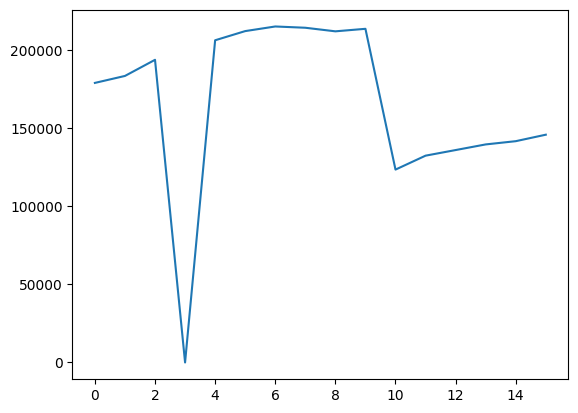

In [207]:
plt.plot(nbbat5)

In [82]:
#### Code à intégrer au précédent : transition d'isolé à cluster d'une année sur l'autre
## On joint la colonne id_cluster de l'année -1 sur la colonne id, et on garde les observations qui étaient à -1 l'année passée et différent de -1 sur l'année suivnate.

df_conv = gdf_meta.merge(gdf_meta_moins1["ID", "id_cluster"], on="ID", how="left", suffixes=("", "_ancien")) ## gdf qui contient aussi l'information sur la bat était un cluster l'année précédente
nbconv1.append(len(df_conv[ (df_conv["id_cluster"]!=-1) & (df_conv["id_cluster_ancien"]==-1),:])) ## On compte tous les bat qui passent d'isolé à cluster 


{'n_clusters_lvl1': 8849,
 'n_noise_lvl1': 148864,
 'n_meta_clusters': 312,
 'n_meta_noise': 3555}

In [98]:
##### On somme et on fait les statistiques descriptives

## nombre clusters
nbclust = [sum(x) for x in zip(nbclust1, nbclust2, nbclust3, nbclust4, nbclust5)]

## nombre de meta clusters
nbmeta = [sum(x) for x in zip(nbmeta1, nbmeta2, nbmeta3, nbmeta4, nbmeta5)]

## surface totale
surf = [sum(x) for x in zip(surf1, surf2, surf3, surf4, surf5)]

## nombre d'isolés
nbisole = [sum(x) for x in zip(nbisole1, nbisole2, nbisole3, nbisole4, nbisole5)]

## Nombre de conversions


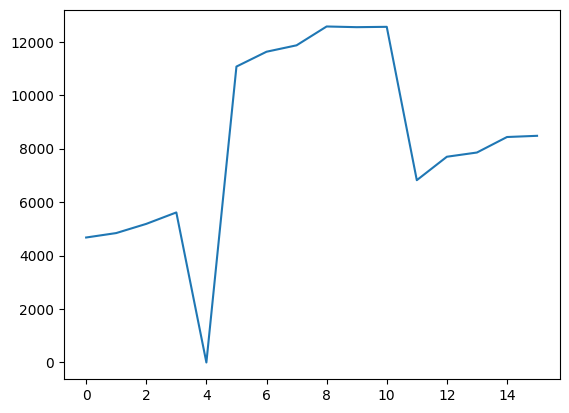

In [208]:
plt.plot(nbclust1)

## Calcul des paramètres optimaux epsilon et min_sample
Pour chaque valeur de min_sample, on cherche le maximum de la dérivée seconde, cela nous permet donc de déduire le meilleur epsilon. On cherche ensuite le min_sample qui mène au coude le plus prononcé. On a ainsi la meilleure paire

In [250]:
def derivee_seconde(y, dt=1):
    y = np.array(y, dtype=float)
    d2y = np.gradient(np.gradient(y, dt), dt)
    return d2y


import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

def dbscan_elbow(gdf, minPts=5, title="Méthode du coude pour DBSCAN"):
    # 1️⃣ Vérification des données
    if 'geometry' not in gdf.columns:
        raise ValueError("Le GeoDataFrame doit contenir une colonne 'geometry'.")

    # 2️⃣ Reprojeter en coordonnées métriques si nécessaire (pour distances physiques)
    if gdf.crs is None:
        raise ValueError("Le GeoDataFrame doit avoir un système de coordonnées défini (CRS).")
    if not gdf.crs.is_projected:
        print("⚠️ Projection en EPSG:3857 pour obtenir des distances en mètres.")
        gdf = gdf.to_crs(epsg=3857)

    # 3️⃣ Extraire les coordonnées des points
    coords = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))

    # 4️⃣ Calcul du k-ième voisin
    k = minPts - 1
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    # 5️⃣ Trier les distances du k-ième plus proche voisin
    distances = np.sort(distances[:, k-1])

    # 6️⃣ Tracer la courbe du coude
    plt.figure(figsize=(8, 5))
    plt.plot(distances)
    plt.title(f"{title} (k = {k})")
    plt.xlabel("Points triés par distance croissante")
    plt.ylabel(f"Distance au {k}-ième plus proche voisin (mètres)")
    plt.grid(True)
    plt.show()

    return distances

def dbscan_elbow_courbe(gdf, minPts=5, title="Méthode du coude pour DBSCAN"):
    # 1️⃣ Vérification des données
    if 'geometry' not in gdf.columns:
        raise ValueError("Le GeoDataFrame doit contenir une colonne 'geometry'.")

    # 2️⃣ Reprojeter en coordonnées métriques si nécessaire (pour distances physiques)
    if gdf.crs is None:
        raise ValueError("Le GeoDataFrame doit avoir un système de coordonnées défini (CRS).")
    if not gdf.crs.is_projected:
        print("⚠️ Projection en EPSG:3857 pour obtenir des distances en mètres.")
        gdf = gdf.to_crs(epsg=3857)

    # 3️⃣ Extraire les coordonnées des points
    coords = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))

    # 4️⃣ Calcul du k-ième voisin
    k = minPts - 1
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    # 5️⃣ Trier les distances du k-ième plus proche voisin
    distances = np.sort(distances[:, k-1])

    # 6️⃣ Tracer la courbe du coude
    plt.figure(figsize=(8, 5))
    plt.plot(distances)
    plt.xlim(2500000, 3000000) 
    plt.title(f"{title} (k = {k+1})")
    plt.xlabel("Points triés par distance croissante")
    plt.xscale("log")
    plt.ylabel(f"Distance au {k}-ième plus proche voisin (mètres)")
    plt.grid(True)
    plt.show()

    return distances

def dbscan_elbow_courbe_meta(gdf, minPts=5, title="Méthode du coude pour DBSCAN Meta"):
    # 1️⃣ Vérification des données
    if 'barycentre' not in gdf.columns:
        raise ValueError("Le GeoDataFrame doit contenir une colonne 'geometry'.")

    # 2️⃣ Reprojeter en coordonnées métriques si nécessaire (pour distances physiques)
    if gdf.crs is None:
        raise ValueError("Le GeoDataFrame doit avoir un système de coordonnées défini (CRS).")
    if not gdf.crs.is_projected:
        print("⚠️ Projection en EPSG:3857 pour obtenir des distances en mètres.")
        gdf = gdf.to_crs(epsg=3857)

    # 3️⃣ Extraire les coordonnées des points
    coords = np.unique(np.array(list(zip(gdf.barycentre.x, gdf.barycentre.y))),axis = 0)

    # 4️⃣ Calcul du k-ième voisin
    k = minPts - 1
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    # 5️⃣ Trier les distances du k-ième plus proche voisin
    distances = np.sort(distances[:, k-1])

    # 6️⃣ Tracer la courbe du coude
    plt.figure(figsize=(8, 5))
    plt.plot(distances)
    plt.title(f"{title} (k = {k+1})")
    plt.xlabel("Points triés par distance croissante")
    plt.xscale("log")
    plt.ylabel(f"Distance au {k}-ième plus proche voisin (mètres)")
    plt.grid(True)
    plt.show()

    return distances


In [248]:
coords = np.unique(np.array(list(zip(gdf_meta_clust.barycentre.x, gdf_meta_clust.barycentre.y))),axis = 0)

# 4️⃣ Calcul du k-ième voisin
k = 4
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(coords)
distances, indices = nbrs.kneighbors(coords)

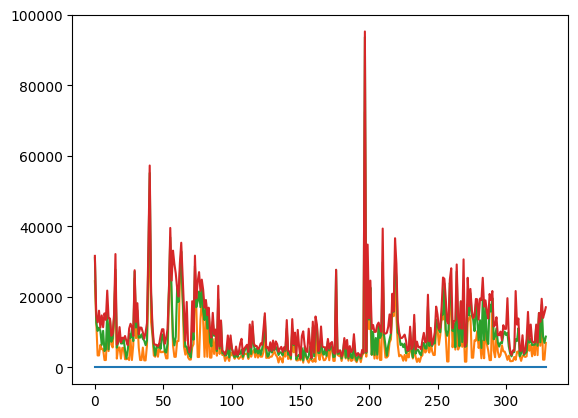

In [249]:
plt.plot(distances)

In [245]:
np.unique(coords,axis = 0)

array([[ 301516.06807222, 6665754.003794  ],
       [ 314792.12339083, 6645173.86669964],
       [ 322556.01700964, 6634999.88490668],
       [ 325313.71966969, 6632991.51332249],
       [ 327538.2255317 , 6644078.08411359],
       [ 328590.14682448, 6650401.62331748],
       [ 331232.6546329 , 6654877.84784028],
       [ 332888.54560452, 6611114.23308888],
       [ 333501.47618614, 6613128.84038298],
       [ 334912.86613509, 6664593.1045019 ],
       [ 337311.08794905, 6609702.97026907],
       [ 343609.77470272, 6622086.43397322],
       [ 354862.29821445, 6629802.17103691],
       [ 356952.35226936, 6639219.74025479],
       [ 358030.94124405, 6658974.85443629],
       [ 359477.63529202, 6593017.69488317],
       [ 360658.51359874, 6626872.27308897],
       [ 361649.76470496, 6632412.88723234],
       [ 362066.78123003, 6641683.2509081 ],
       [ 362665.57630213, 6625353.71303837],
       [ 369053.32996155, 6627722.84920685],
       [ 369776.64106784, 6633223.4507892 ],
       [ 3

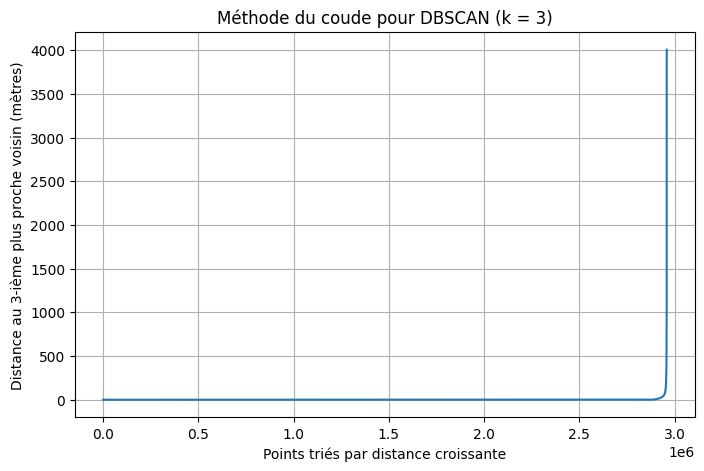

In [136]:
a = dbscan_elbow(gdf,minPts = 4)

(2800000, 3000000)

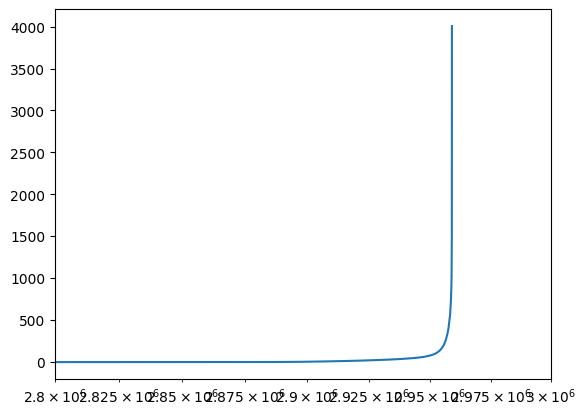

In [137]:
plt.plot(a)
plt.xscale("log")
plt.xlim(2800000, 3000000) 

In [128]:
from sklearn.metrics import silhouette_score

# coords = tableau des coordonnées (x, y)
coords = np.column_stack([test.geometry.centroid.x, test.geometry.centroid.y])
labels = test["id_cluster"]

# on exclut le bruit (-1)
mask = labels != -1
sil_score = silhouette_score(coords[mask], labels[mask])
sil_score

0.8716200031631621

In [139]:
np.gradient(a)

array([  0.        ,   0.        ,   0.        , ...,  87.33824191,
       107.01101051,  56.1143716 ], shape=(2958999,))

In [140]:
import numpy as np

def moving_average(y, window_size=5):
    return np.convolve(y, np.ones(window_size)/window_size, mode='valid')


In [178]:
b = moving_average(a,window_size=10000)

In [179]:
c = np.gradient(np.gradient(b))

(2958000.0, 2960000.0)

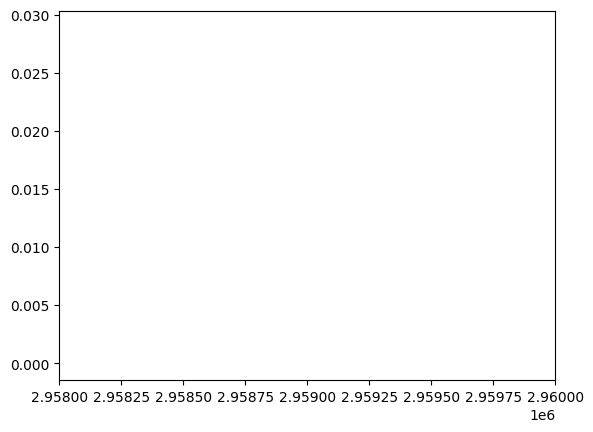

In [181]:
plt.plot(c)
plt.xlim(2958000, 2960000) 

In [182]:
!pip install kneed

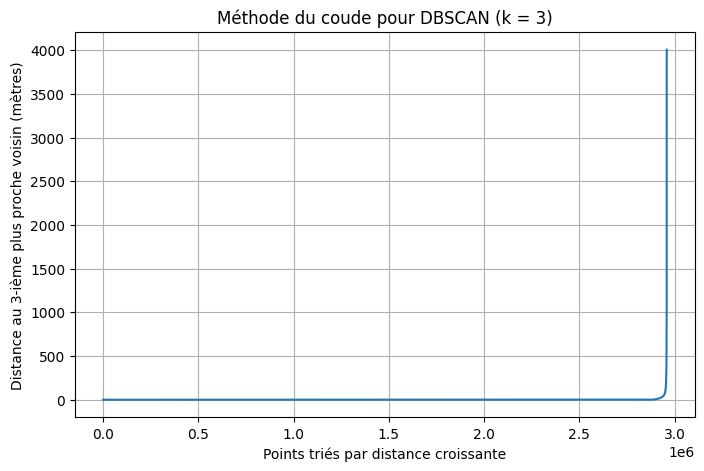

np.float64(1425.500074852785)

In [204]:
from kneed import KneeLocator
a = dbscan_elbow(gdf,minPts = 4)
x = np.arange(1, len(a) + 1)
y = a
knee = KneeLocator(x, y, curve='convex', direction='increasing')
a[knee.knee-1]

In [194]:
knee.knee

np.int64(2958999)

In [222]:
####
#### METHODE DU COUDE SUR LES METACLUSTER
####



def ajouter_barycentre_par_metacluster(gdf, cluster_col="id_meta_cluster"):
    # 1️⃣ Vérifications de base
    if cluster_col not in gdf.columns:
        raise ValueError(f"La colonne '{cluster_col}' n'existe pas dans le GeoDataFrame.")
    if 'geometry' not in gdf.columns:
        raise ValueError("Le GeoDataFrame doit contenir une colonne 'geometry'.")
    
    gdf_copy = gdf.copy()
    
    # 2️⃣ Si géométries non projetées, avertir
    if gdf_copy.crs is None:
        raise ValueError("Le GeoDataFrame doit avoir un CRS défini pour calculer les barycentres.")
    if not gdf_copy.crs.is_projected:
        print("⚠️ Le CRS n'est pas projeté. Projection temporaire en EPSG:3857 pour le calcul en mètres.")
        gdf_copy = gdf_copy.to_crs(epsg=3857)
    
    # 3️⃣ Calcul des barycentres par groupe
    # Dissolve (fusionne) les géométries par méta-cluster
    barycentres = gdf_copy.dissolve(by=cluster_col, as_index=False)[[cluster_col, "geometry"]]
    
    # Calcul du centroïde de chaque groupe
    barycentres["barycentre"] = barycentres.geometry.centroid
    
    # 4️⃣ Fusion des barycentres avec le gdf original
    gdf_final = gdf_copy.merge(
        barycentres[[cluster_col, "barycentre"]],
        on=cluster_col,
        how="left"
    )
    
    return gdf_final
    

gdf_meta_clust = ajouter_barycentre_par_metacluster(gdf_meta)
dbscan_elbow_courbe_meta(gdf_meta_clust)

AttributeError: 'GeoSeries' object has no attribute 'barycentre'

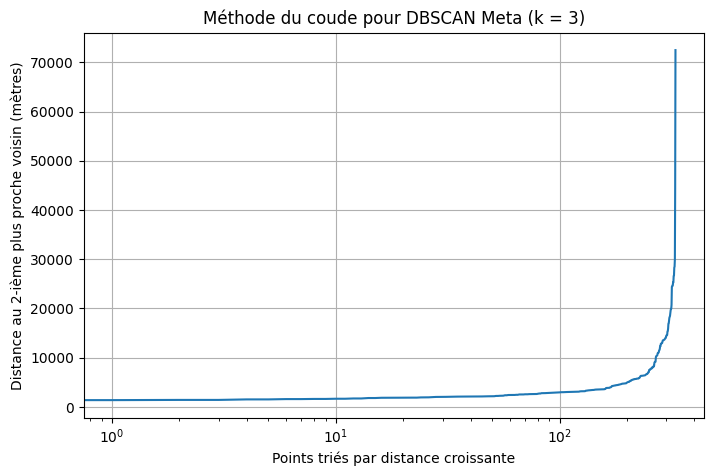

array([ 1363.4326021 ,  1363.4326021 ,  1405.64306939,  1405.64306939,
        1509.78884074,  1509.78884074,  1573.18143766,  1573.18143766,
        1604.37079191,  1604.37079191,  1644.2763151 ,  1644.2763151 ,
        1699.919142  ,  1699.919142  ,  1789.77878741,  1789.77878741,
        1839.93443167,  1839.93443167,  1853.95926162,  1853.95926162,
        1866.52461247,  1866.52461247,  1869.05509131,  1869.05509131,
        1914.59622733,  1914.59622733,  1930.63862401,  1980.09688652,
        2010.78318636,  2010.78318636,  2028.74191894,  2028.74191894,
        2046.50315725,  2046.50315725,  2076.92850568,  2076.92850568,
        2088.66417371,  2088.66417371,  2089.74126829,  2089.74126829,
        2105.78404575,  2105.78404575,  2106.07144962,  2106.07144962,
        2110.71541169,  2110.71541169,  2126.61943847,  2126.61943847,
        2142.91678697,  2142.91678697,  2156.4261721 ,  2156.4261721 ,
        2214.45396757,  2214.45396757,  2243.97538681,  2243.97538681,
      

In [255]:
dbscan_elbow_courbe_meta(gdf_meta_clust,minPts = 3)

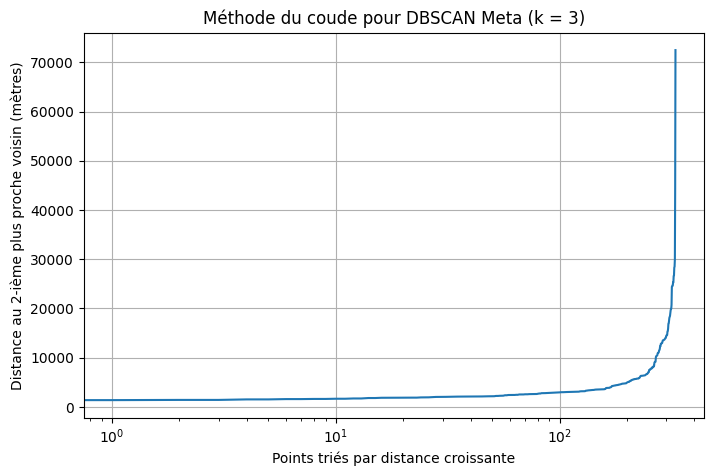

np.float64(24651.665533514366)

In [256]:
from kneed import KneeLocator
a = dbscan_elbow_courbe_meta(gdf_meta_clust,minPts = 3)
x = np.arange(1, len(a) + 1)
y = a
knee = KneeLocator(x, y, curve='convex', direction='increasing')
a[knee.knee-1]

## Métriques de  qualité du cluster

In [195]:
from sklearn.metrics import silhouette_score
#### Silhouette_score

# coords = tableau des coordonnées (x, y)
coords = np.column_stack([test.geometry.centroid.x, test.geometry.centroid.y])
labels = test["id_cluster"]

# on exclut le bruit (-1)
mask = labels != -1
sil_score = silhouette_score(coords[mask], labels[mask])
sil_score

#### 

import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

def grid_search_dbscan(X, eps_list, min_samples_list,
                       max_noise=0.3, min_clusters=2):
    best = None
    results = []
    for ms in min_samples_list:
        for eps in eps_list:
            lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
            n_noise = np.mean(lab == -1)
            n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
            sil = np.nan
            if n_clusters >= min_clusters and n_noise <= max_noise:
                mask = lab != -1
                if mask.sum() > n_clusters:  # au moins 1 point/cluster
                    sil = silhouette_score(X[mask], lab[mask])
            row = dict(eps=eps, min_samples=ms,
                       silhouette=sil, noise=n_noise, n_clusters=n_clusters)
            results.append(row)
            if not np.isnan(sil):
                if best is None or sil > best["silhouette"]:
                    best = row
    return best, results


In [ ]:
Coordo = np.column_stack([
    gdf.geometry.centroid.x,
    gdf.geometry.centroid.y
])

li_ep = [x*40  for x in range(1,100)]
meilleur , swag = grid_search_dbscan(Coordo, eps_list = li_ep, min_samples_list = range(1,20))


# Etude sur la rupture de tendance forte

Pour comprendre pourquoi on a 2 ruptures de tendance, il convient de comprendre ce qui se passe aux deux points clés.
Deux métriques vont être utilisées : 
- le nombre de bâtiments, cela peut expliquer l'effondrement des clusters.
- On va faire un tracking des batiments. On prend tous les batiments présents en 2009 et on voit la proportion de ceux qui le sont encore en n.

In [ ]:
gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg")
## Dataframe que l'on va exploiter

## Tracking bâtiments

In [10]:
### On 
gdf[gdf.ID == "BATIMENT0000000051915382"]

,ID,Annee,Dep,ORIGIN_BAT,NATURE,HAUTEUR,USAGE1,USAGE2,ETAT,DATE_CREAT,DATE_MAJ,ID_SOURCE,SOURCE,geometry
0,BATIMENT0000000051915382,2011,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((636592.3 6317214.3 183.9, 636624.2..."
17870,BATIMENT0000000051915382,2012,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((636592.3 6317214.3 183.9, 636624.2..."
55489,BATIMENT0000000051915382,2014,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((636592.3 6317214.3 183.9, 636624.2..."
93974,BATIMENT0000000051915382,2013,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((636592.3 6317214.3 183.9, 636624.2..."
132606,BATIMENT0000000051915382,2008,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((636592.3 6317214.3 183.9, 636624.2..."
149353,BATIMENT0000000051915382,2009,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((636592.3 6317214.3 183.9, 636624.2..."
167194,BATIMENT0000000051915382,2010,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((636592.3 6317214.3 183.9, 636624.2..."


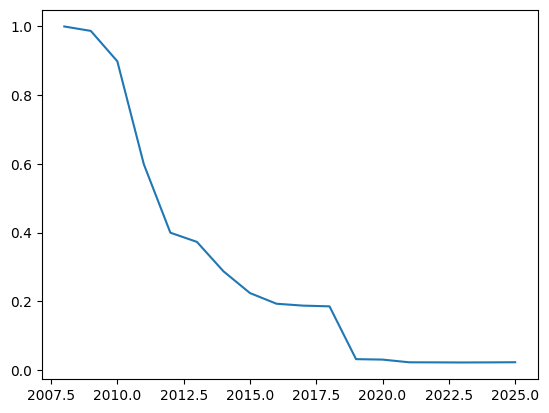

In [18]:
## On prend la liste des bâtiments en 2008
list_2008 = gdf[gdf.Annee == 2008].ID
## On garde que les bats présents en 2008
gdf_8 = gdf[gdf.ID.isin(list_2008)]
gdf_8

prop = []
for an in range(2008,2026):
    prop.append(len(gdf_8[gdf_8.Annee==an])/len(list_2008))

plt.plot(list(range(2008,2026)),prop)

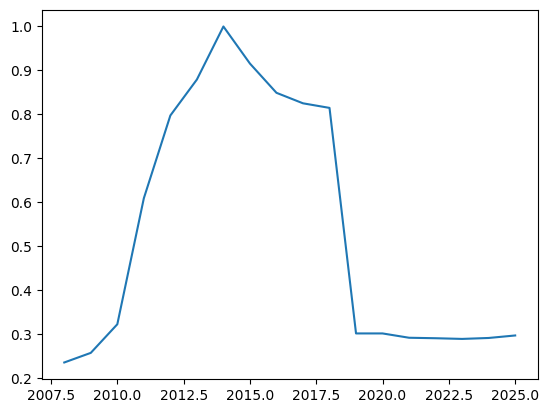

In [22]:
## On prend la liste des bâtiments en 2008
list_2014 = gdf[gdf.Annee == 2014].ID
## On garde que les bats présents en 2016
gdf_14 = gdf[gdf.ID.isin(list_2014)]
gdf_14

prop = []
for an in range(2008,2026):
    prop.append(len(gdf_14[gdf_14.Annee==an])/len(list_2014))

plt.plot(list(range(2008,2026)),prop)

On observe vraiment un effondrement des IDs au moment du changement de base BDTopo. Cependant, on observe aussi un comportement bizarre vers 2010-2011, il faudrait pouvoir le caractériser. On va tracer le nombre de bâtiments pour voir si on a une telle rupture ou si c'est juste une perte de mémoire.

Text(0.5, 1.0, 'Nombre de bâtiments')

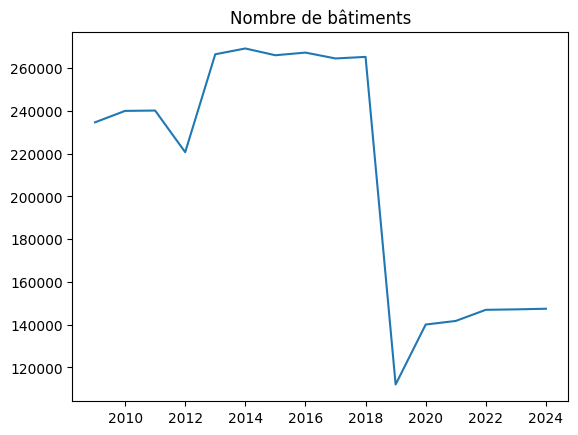

In [41]:
plt.plot(list(range(2009,2025)),nbbat1)
plt.title("Nombre de bâtiments")

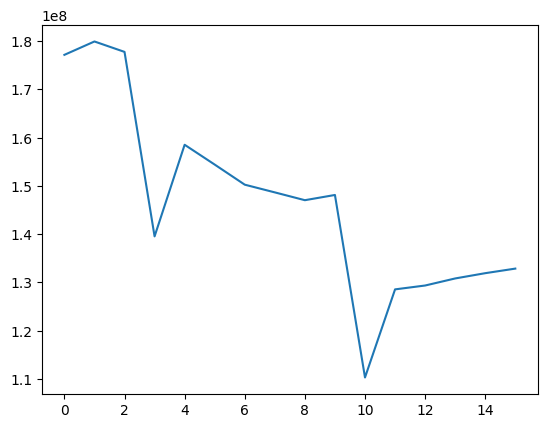

In [32]:
plt.plot(list(range(2009,2025)),surf1)
plt.title("Surface totale")

Il semble que le nombre de batiments soit cohérent (voir un petit rebond en 2010-2011). Il convient cependant de voir s'il n'y a pas eu une redéfinition de la notion de bâtiment. Pour cela tracer la surface moyenne d'un bâtiment.

Text(0.5, 1.0, 'Surface moyenne')

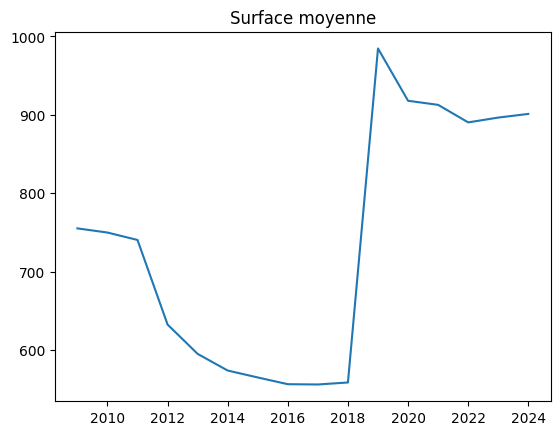

In [42]:
plt.plot(list(range(2009,2025)),np.array(surf1)/np.array(nbbat1))
plt.title("Surface moyenne")

On observe un effondrement de la surface moyenne vers 2010-2011 qui est drivé aussi bien par une baisse de la surface industrialisée, que par une augmentation du nombre de bâtiments.

Text(0.5, 1.0, 'Taux de conversion cluster')

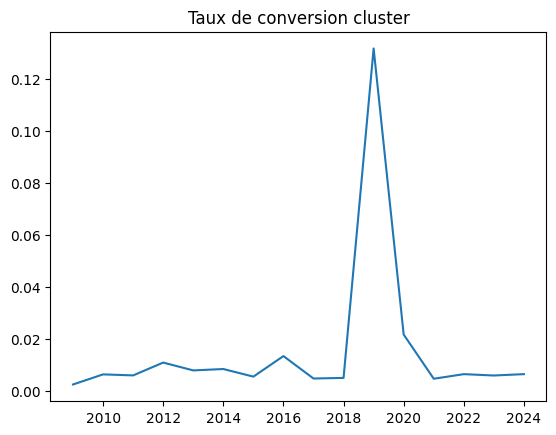

In [50]:
## Taux de conversion
plt.plot(list(range(2009,2025)),nbconv1)
plt.title("Taux de conversion cluster")

# Nouvelle définition du Méta Cluster - Raisonnement sur des batiments de grande taille.

Dans cette partie, on va faire une nouvelle fonction de meta clusturing mais qui va aussi prendre en compte les bruits du premier clusturing pour calculer le meta cluster.

In [65]:
####Fonction meta cluster : test en local avant de mettre dans fonctions

import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.cluster import DBSCAN

def gdf_meta_DBSCAN2(gdf: gpd.GeoDataFrame,
                    annee: int,
                    eps1: float,
                    eps2: float,
                    min_sample: int = 4):
    # 1) Filtre année
    gdf_annee = gdf[gdf["Annee"] == annee].copy()
    if len(gdf_annee) == 0:
        gdf_annee["centroid"] = pd.Series(dtype="object")
        gdf_annee["id_cluster"] = pd.Series(dtype="int64")
        gdf_annee["id_meta_cluster"] = pd.Series(dtype="int64")
        return gdf_annee, dict(n_clusters_lvl1=0, n_noise_lvl1=0,
                               n_meta_clusters=0, n_meta_noise=0)

    # 2) CRS métrique
    if gdf_annee.crs is None or not gdf_annee.crs.is_projected:
        gdf_annee = gdf_annee.to_crs(2154)

    # 3) Centroids
    gdf_annee["centroid"] = gdf_annee.geometry.centroid
    coords = np.column_stack([gdf_annee["centroid"].x.values,
                              gdf_annee["centroid"].y.values])

    # 4) DBSCAN niveau 1
    db1 = DBSCAN(eps=eps1, min_samples=min_sample)
    labels1 = db1.fit_predict(coords)
    gdf_annee["id_cluster"] = labels1.astype(int)

    n_clusters_lvl1 = int(len(set(labels1)) - (1 if -1 in labels1 else 0))
    n_noise_lvl1 = int(np.sum(labels1 == -1))


    #######
    ####### MODIFIFCATION : ON MET UN LABEL NEGATIF POUR LES BRUITS CAR UTILE POUR LE DEUXI7ME CLUSTURING;

    gdf_annee.loc[gdf_annee.id_cluster == -1,"id_cluster"] = -np.array(list(range(1,len(gdf_annee[gdf_annee.id_cluster == -1])+1))) ## On met un indice -1 comme cela c'est plus clair.

    # 5) Barycentres (clusters != -1)
    mask_clusters = (gdf_annee["id_cluster"].values <0 )  ### On change la consition en nombre strictement négatif conformément à l'opération au dessus
    if mask_clusters.any():
        df_centroids_clust = ( ### C'est les centroides des clusters!!
            gdf_annee.loc[mask_clusters, ["id_cluster", "centroid"]]
            .assign(x=lambda d: d["centroid"].x,
                    y=lambda d: d["centroid"].y)
            .groupby("id_cluster", as_index=False)[["x", "y"]].mean()
        )

        df_centroids_isol = gdf_annee.loc[~mask_clusters, ["id_cluster", "centroid"]].assign(x=lambda d: d["centroid"].x, y=lambda d: d["centroid"].y) ## On fait les barycentres sur les points isolés

        df_centroids = pd.concat([df_centroids_clust, df_centroids_isol], axis=0, ignore_index=True)

        # 6) DBSCAN niveau 2 sur barycentres (ceux des clusters et ceux des points isolés

        bary_coords = np.column_stack([df_centroids["x"].values, df_centroids["y"].values])
        db2 = DBSCAN(eps=eps2, min_samples=min_sample)
        labels2 = db2.fit_predict(bary_coords)

        # 7) Remappage des labels de méta-clusters en 0..K-1 (en conservant -1)
        uniq = sorted([l for l in set(labels2) if l != -1])
        remap = {old: new for new, old in enumerate(uniq)}
        meta_labels = pd.Series(labels2).map(remap).fillna(-1).astype(int).to_numpy()

        # 8) Propagation aux entités d'origine
        meta_map = dict(zip(df_centroids["id_cluster"].astype(int).tolist(),
                            meta_labels.tolist()))
        gdf_annee["id_meta_cluster"] = gdf_annee["id_cluster"].map(meta_map).fillna(-1).astype(int)

        n_meta_clusters = int(len(uniq))
        n_meta_noise = int(np.sum(labels2 == -1))


    # (optionnel) logs
    print(f"[Niveau 1] Clusters: {n_clusters_lvl1} | Bruit: {n_noise_lvl1}")
    print(f"[Niveau 2] Méta-clusters: {n_meta_clusters} | Bruit (barycentres): {n_meta_noise}")

    return gdf_annee, dict(
        n_clusters_lvl1=n_clusters_lvl1,
        n_noise_lvl1=n_noise_lvl1,
        n_meta_clusters=n_meta_clusters,
        n_meta_noise=n_meta_noise
    )


        


#### TEST

test , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  2008,
                    eps1 =  50,
                    eps2 =  1000,
                    min_sample= 5)

[Niveau 1] Clusters: 1769 | Bruit: 219330
[Niveau 2] Méta-clusters: 4869 | Bruit (barycentres): 16447


### On applique maintenant cette nouvelle dfinition aux codes qu'on a eu avant pour l'autre meta db scan

In [115]:
len(gdf_meta[gdf_meta.id_cluster_moins <0 ])

136576

In [ ]:
#### département 1 à 20

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_1_20.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf1 = []
nbclust1 = []
nbmeta1 = []
nbisole1 = []
nbconv1 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année
nbbat1 = []
for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf1.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust1.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta1.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole1.append(stat["n_noise_lvl1"])

    ## nb batiments
    nbbat1.append(len(gdf_meta))
    ## nb conv : On verra pour l'implémenter plus tard
    # On commence par merger gdf meta et meta moins1 sur id pour rajouter l'id clu
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv1.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

#### département 21 à 40

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_21_40.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf2 = []
nbclust2 = []
nbmeta2 = []
nbisole2 = []
nbconv2 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf2.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust2.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta2.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole2.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv2.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

#### département 41 à 60

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_41_60.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf3 = []
nbclust3 = []
nbmeta3 = []
nbisole3 = []
nbconv3 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf3.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust3.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta3.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole3.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv3.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

#### département 61 à 80

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_61_80.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf4 = []
nbclust4 = []
nbmeta4 = []
nbisole4 = []
nbconv4 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf4.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust4.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta4.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole4.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv4.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))


#### département 81 à 99

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf5 = []
nbclust5 = []
nbmeta5 = []
nbisole5 = []
nbconv5 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année
nbbat5 = []

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des indus
    surf5.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust5.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta5.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole5.append(stat["n_noise_lvl1"])

    ## nb bat 
    nbbat5.append(len(gdf_meta))
    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv5.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

##### On somme et on fait les statistiques descriptives

## nombre clusters
nbclust = [sum(x) for x in zip(nbclust1, nbclust2, nbclust3, nbclust4, nbclust5)]

## nombre de meta clusters
nbmeta = [sum(x) for x in zip(nbmeta1, nbmeta2, nbmeta3, nbmeta4, nbmeta5)]

## surface totale
surf = [sum(x) for x in zip(surf1, surf2, surf3, surf4, surf5)]

## nombre d'isolés
nbisole = [sum(x) for x in zip(nbisole1, nbisole2, nbisole3, nbisole4, nbisole5)]

## Nombre de conversions
nbconv = [sum(x) for x in zip(nbconv1, nbconv2, nbconv3, nbconv4, nbconv5)]


Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_1_20.gpkg ...


### Etude de la distribution des tailles des bâtiments selon les années



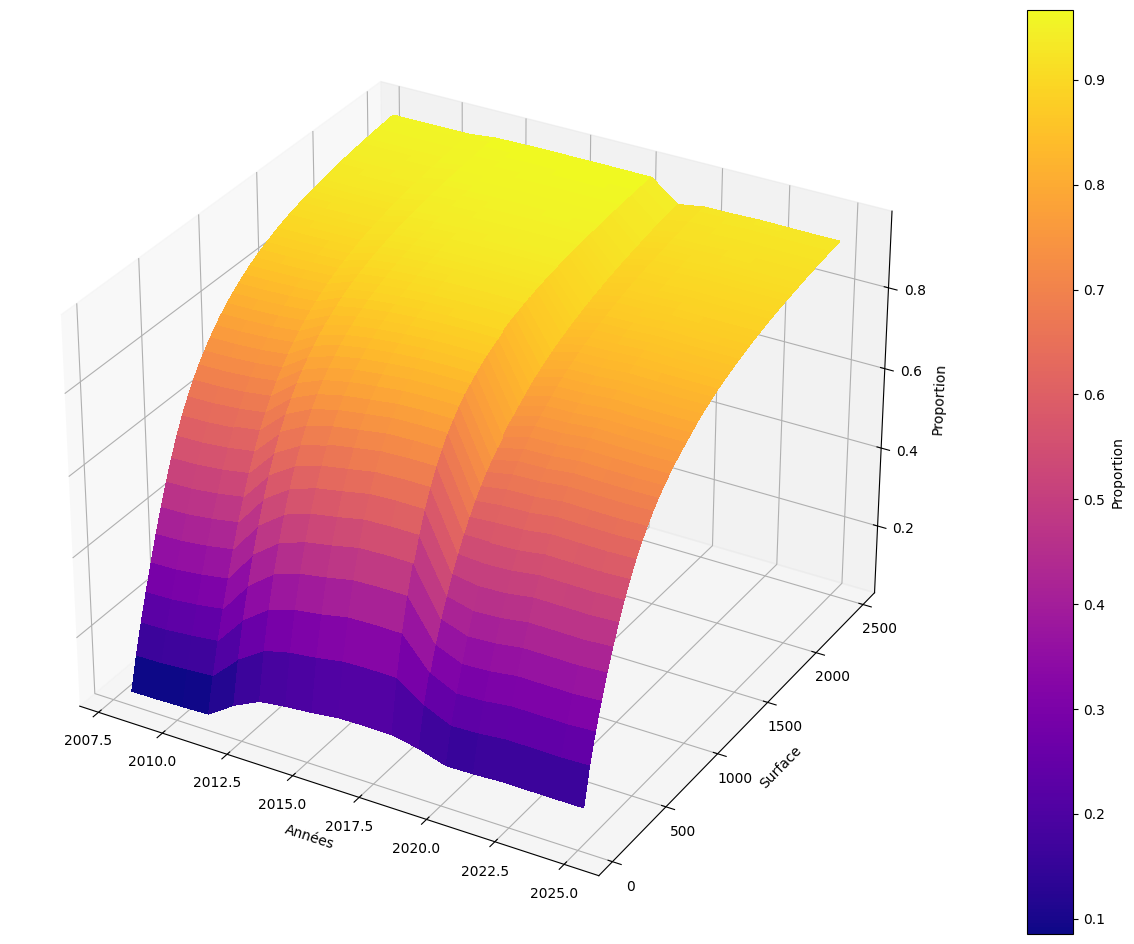

In [109]:
## Hors couleur

#########
######### Forme pour chaque année : un df trois colonnes : surf, année 
#########
from matplotlib import cm
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D 

nappe = pd.DataFrame(columns = ["Surface","Années","Proportion"])
distrib =list(np.array(list(range(1,50)))*50)
nappe.Surface = list(np.array(list(range(1,50)))*50)*(2025-2008+1) ## Le nombre d'années
nappe.Années = [i for i in range(2008, 2026) for _ in range(len(distrib))]

for an in range(2008,2026):
    prop = [] ## vecteur des proportions inféreures ou égales
    surf_vec = gdf[gdf.Annee == an].geometry.area
    for surface in distrib:
        prop.append(len(surf_vec[surf_vec<surface])/len(surf_vec))
    nappe.loc[nappe.Années == an,"Proportion"] = prop
nappe

tab = nappe.pivot_table(index='Surface', columns='Années', values='Proportion')
X, Y = np.meshgrid(tab.columns.values, tab.index.values)
Z = tab.values

fig = plt.figure(figsize=(24, 12))
ax = fig.add_subplot(111, projection='3d')

# Couleurs contrôlées par Z
surf = ax.plot_surface(X, Y, Z,cmap=cm.plasma,     # <- change ici : 'viridis', 'plasma', 'inferno', 'cividis', ...
                       linewidth=0,
                       antialiased=False)  # nappe
fig.colorbar(surf, ax=ax, label="Proportion") 
ax.set_xlabel("Années"); ax.set_ylabel("Surface"); ax.set_zlabel("Proportion")
plt.show()

De ce qui précède, on voit qu'en prenant une surface de 500m^2, il nous reste environ 40% des bâtiments. Cela peut reste satisfaisant. Pour 200m^2, il resterait 40%


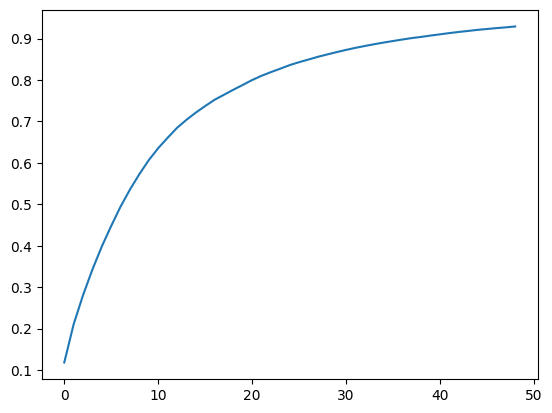

In [112]:
plt.plot(prop)

Distrib en 2025, l'axe x est à multiplier par 50 pour obtenir la surface

# Etude pour les bâtiments d'aire supérieure à 200m^2

On plot toutes les stat desc uniquement en conservant les batiments de plus de 200m^2

In [116]:
#### département 1 à 20

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_1_20.gpkg")
gdf = gdf[gdf.geometry.area >200]

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf1 = []
nbclust1 = []
nbmeta1 = []
nbisole1 = []
nbconv1 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année
nbbat1 = []
for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf1.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust1.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta1.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole1.append(stat["n_noise_lvl1"])

    ## nb batiments
    nbbat1.append(len(gdf_meta))
    ## nb conv : On verra pour l'implémenter plus tard
    # On commence par merger gdf meta et meta moins1 sur id pour rajouter l'id clu
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv1.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

#### département 21 à 40

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_21_40.gpkg")
gdf = gdf[gdf.geometry.area >200]


## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf2 = []
nbclust2 = []
nbmeta2 = []
nbisole2 = []
nbconv2 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf2.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust2.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta2.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole2.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv2.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

#### département 41 à 60

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_41_60.gpkg")
gdf = gdf[gdf.geometry.area >200]


## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf3 = []
nbclust3 = []
nbmeta3 = []
nbisole3 = []
nbconv3 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf3.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust3.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta3.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole3.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv3.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

#### département 61 à 80

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_61_80.gpkg")
gdf = gdf[gdf.geometry.area >200]


## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf4 = []
nbclust4 = []
nbmeta4 = []
nbisole4 = []
nbconv4 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf4.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust4.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta4.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole4.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv4.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))


#### département 81 à 99

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg")
gdf = gdf[gdf.geometry.area >200]


## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf5 = []
nbclust5 = []
nbmeta5 = []
nbisole5 = []
nbconv5 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année
nbbat5 = []

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des indus
    surf5.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust5.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta5.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole5.append(stat["n_noise_lvl1"])

    ## nb bat 
    nbbat5.append(len(gdf_meta))
    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv5.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

##### On somme et on fait les statistiques descriptives

## nombre clusters
nbclust = [sum(x) for x in zip(nbclust1, nbclust2, nbclust3, nbclust4, nbclust5)]

## nombre de meta clusters
nbmeta = [sum(x) for x in zip(nbmeta1, nbmeta2, nbmeta3, nbmeta4, nbmeta5)]

## surface totale
surf = [sum(x) for x in zip(surf1, surf2, surf3, surf4, surf5)]

## nombre d'isolés
nbisole = [sum(x) for x in zip(nbisole1, nbisole2, nbisole3, nbisole4, nbisole5)]

## Nombre de conversions
nbconv = [sum(x) for x in zip(nbconv1, nbconv2, nbconv3, nbconv4, nbconv5)]


Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_1_20.gpkg ...


KeyboardInterrupt: 

In [ ]:
plt.plot(nbclust)

In [ ]:
plt.plot(nbmeta)

In [ ]:
plt.plot(surf)

In [ ]:
plt.plot(nbisole)

In [ ]:
plt.plot(nbconv)